### 强化学习训练

开始GRPO算法训练
第 10/150 轮 | 平均奖励: -2105.62 | 学习率: 0.000500 | 最佳奖励: -2090.54
第 20/150 轮 | 平均奖励: -1816.89 | 学习率: 0.000250 | 最佳奖励: -1816.89
第 30/150 轮 | 平均奖励: -1793.51 | 学习率: 0.000250 | 最佳奖励: -1716.24
第 40/150 轮 | 平均奖励: -1617.44 | 学习率: 0.000125 | 最佳奖励: -1601.85
第 50/150 轮 | 平均奖励: -1524.68 | 学习率: 0.000125 | 最佳奖励: -1524.68
第 60/150 轮 | 平均奖励: -1521.13 | 学习率: 0.000063 | 最佳奖励: -1471.71
第 70/150 轮 | 平均奖励: -1433.36 | 学习率: 0.000063 | 最佳奖励: -1414.06
第 80/150 轮 | 平均奖励: -1452.97 | 学习率: 0.000031 | 最佳奖励: -1368.31
第 90/150 轮 | 平均奖励: -1383.47 | 学习率: 0.000031 | 最佳奖励: -1322.93
第 100/150 轮 | 平均奖励: -1337.81 | 学习率: 0.000016 | 最佳奖励: -1322.93
第 110/150 轮 | 平均奖励: -1371.73 | 学习率: 0.000016 | 最佳奖励: -1322.93
第 120/150 轮 | 平均奖励: -1364.43 | 学习率: 0.000008 | 最佳奖励: -1318.51
第 130/150 轮 | 平均奖励: -1341.24 | 学习率: 0.000008 | 最佳奖励: -1318.51
第 140/150 轮 | 平均奖励: -1380.49 | 学习率: 0.000004 | 最佳奖励: -1318.51
第 150/150 轮 | 平均奖励: -1347.46 | 学习率: 0.000004 | 最佳奖励: -1318.51
训练完成 | 最终平均奖励: -1362.89 | 历史最佳奖励: -1318.51


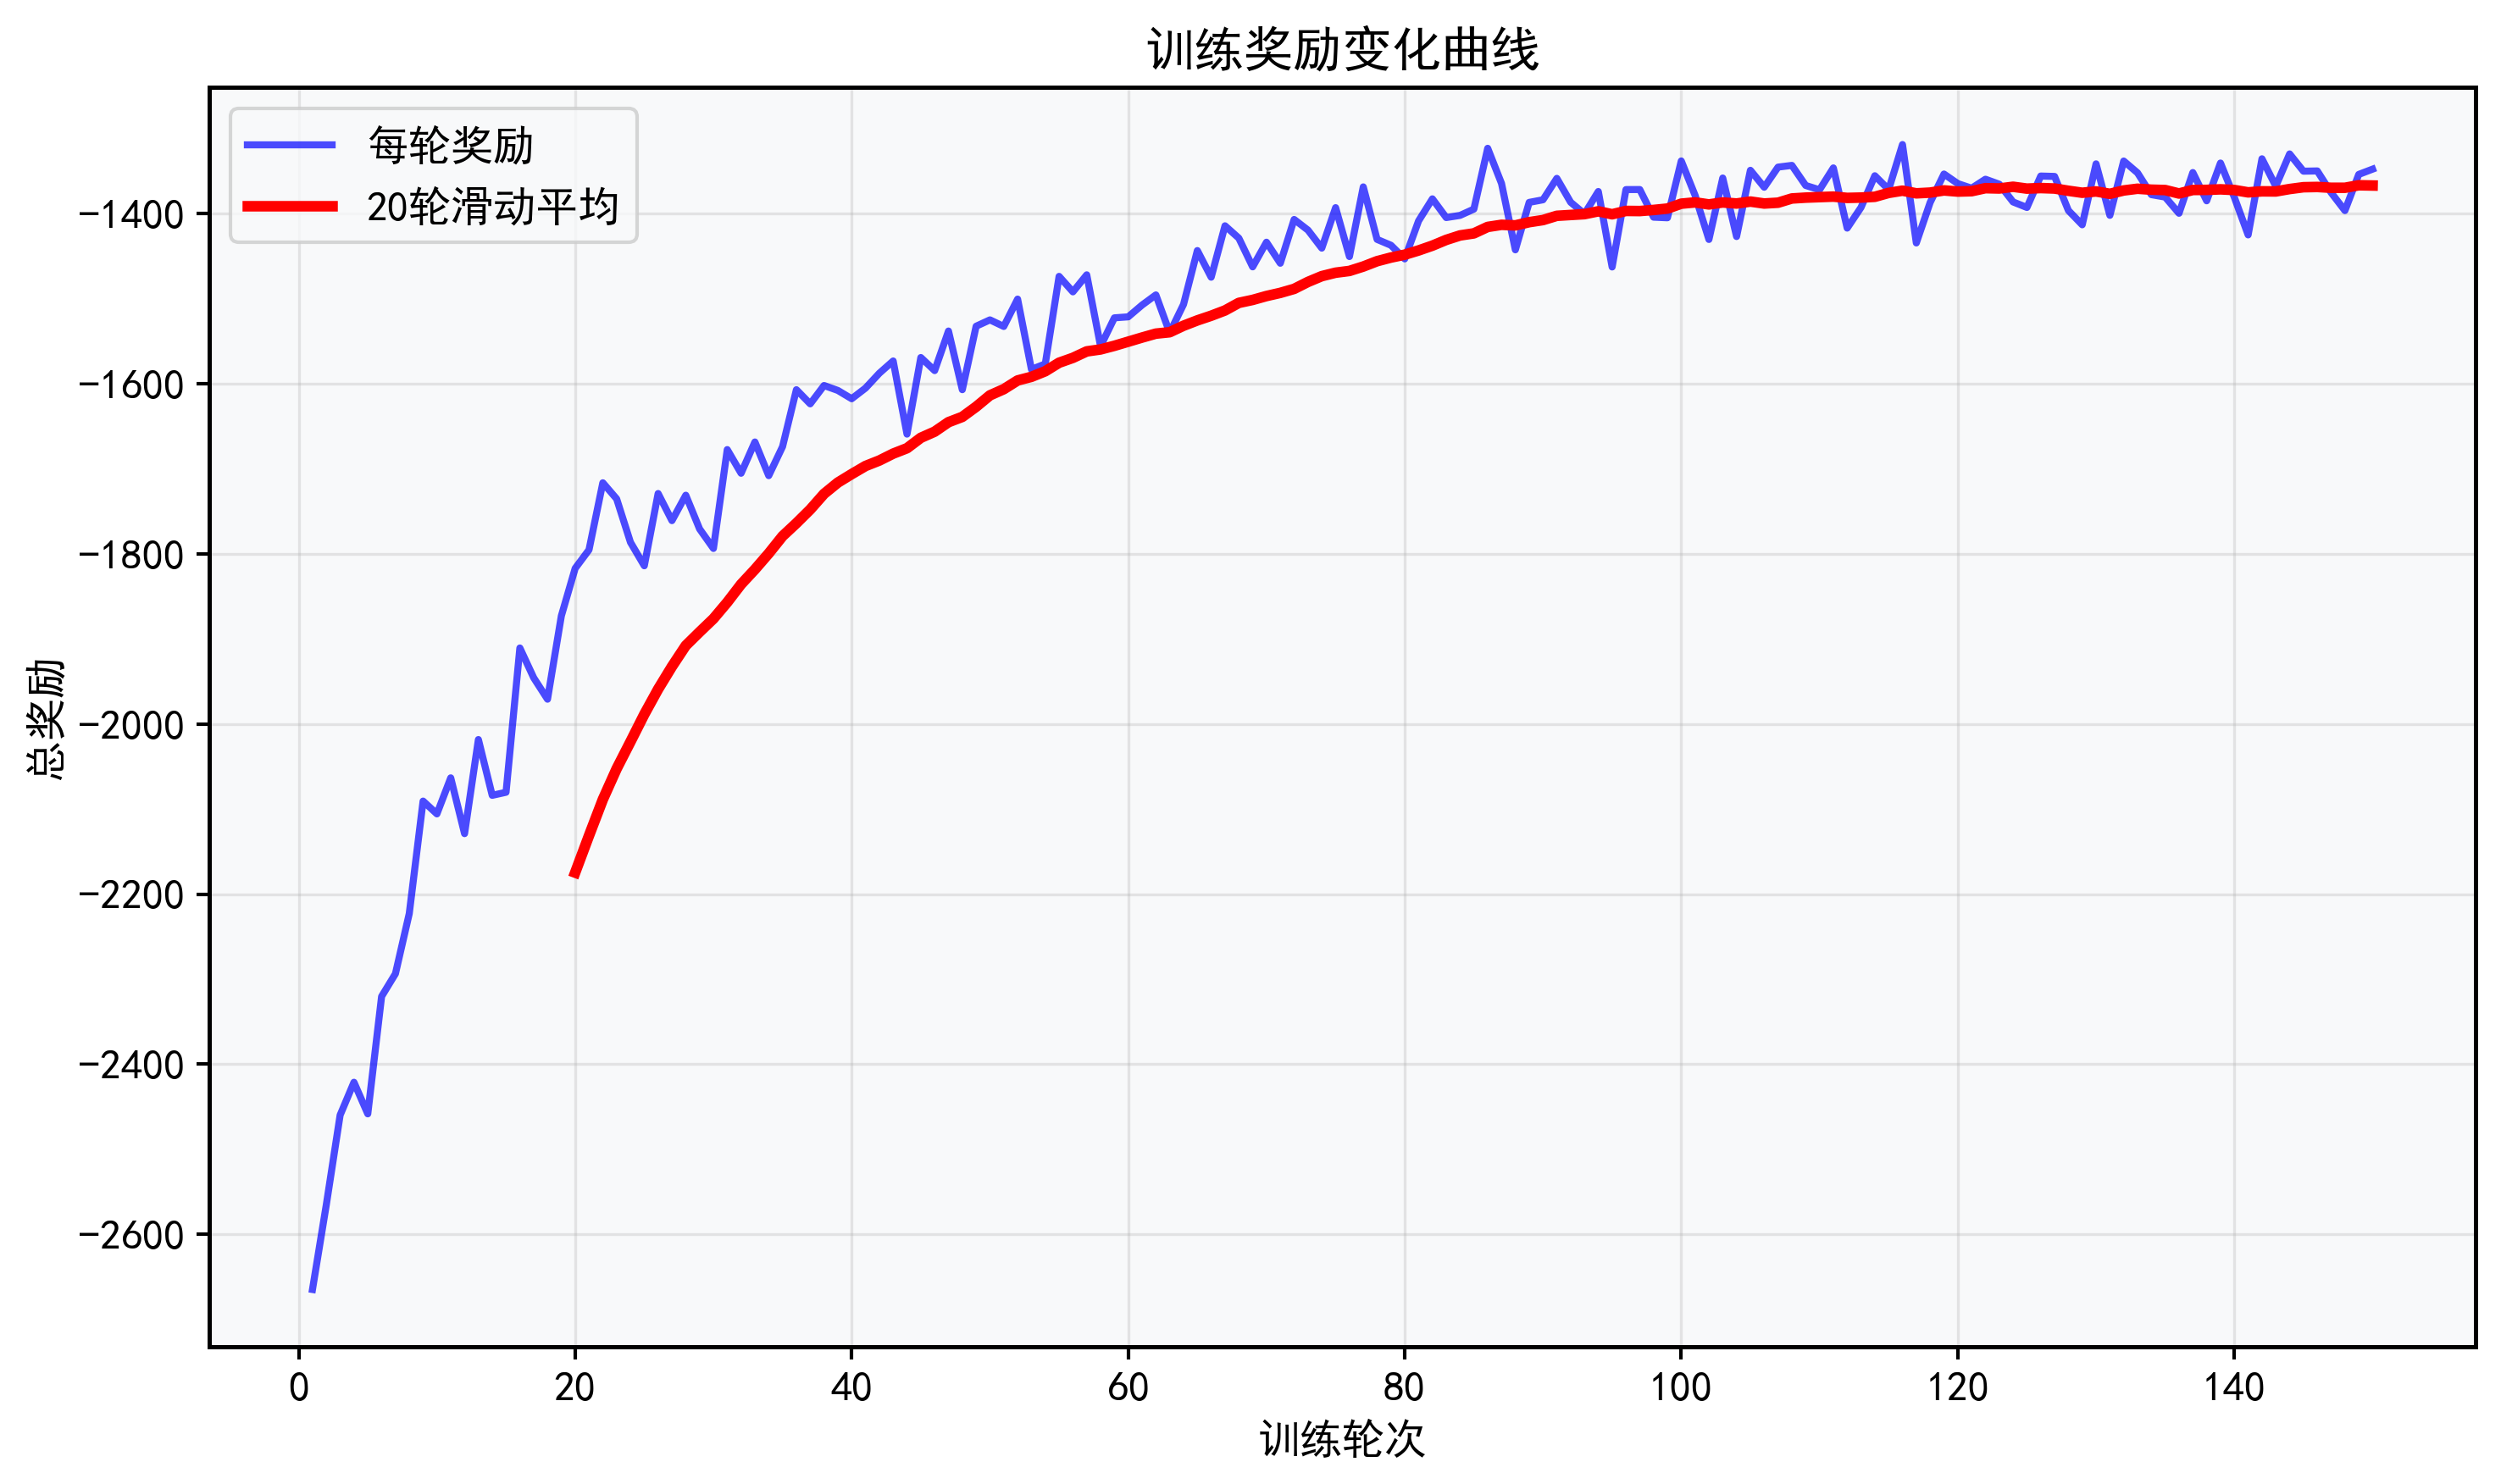

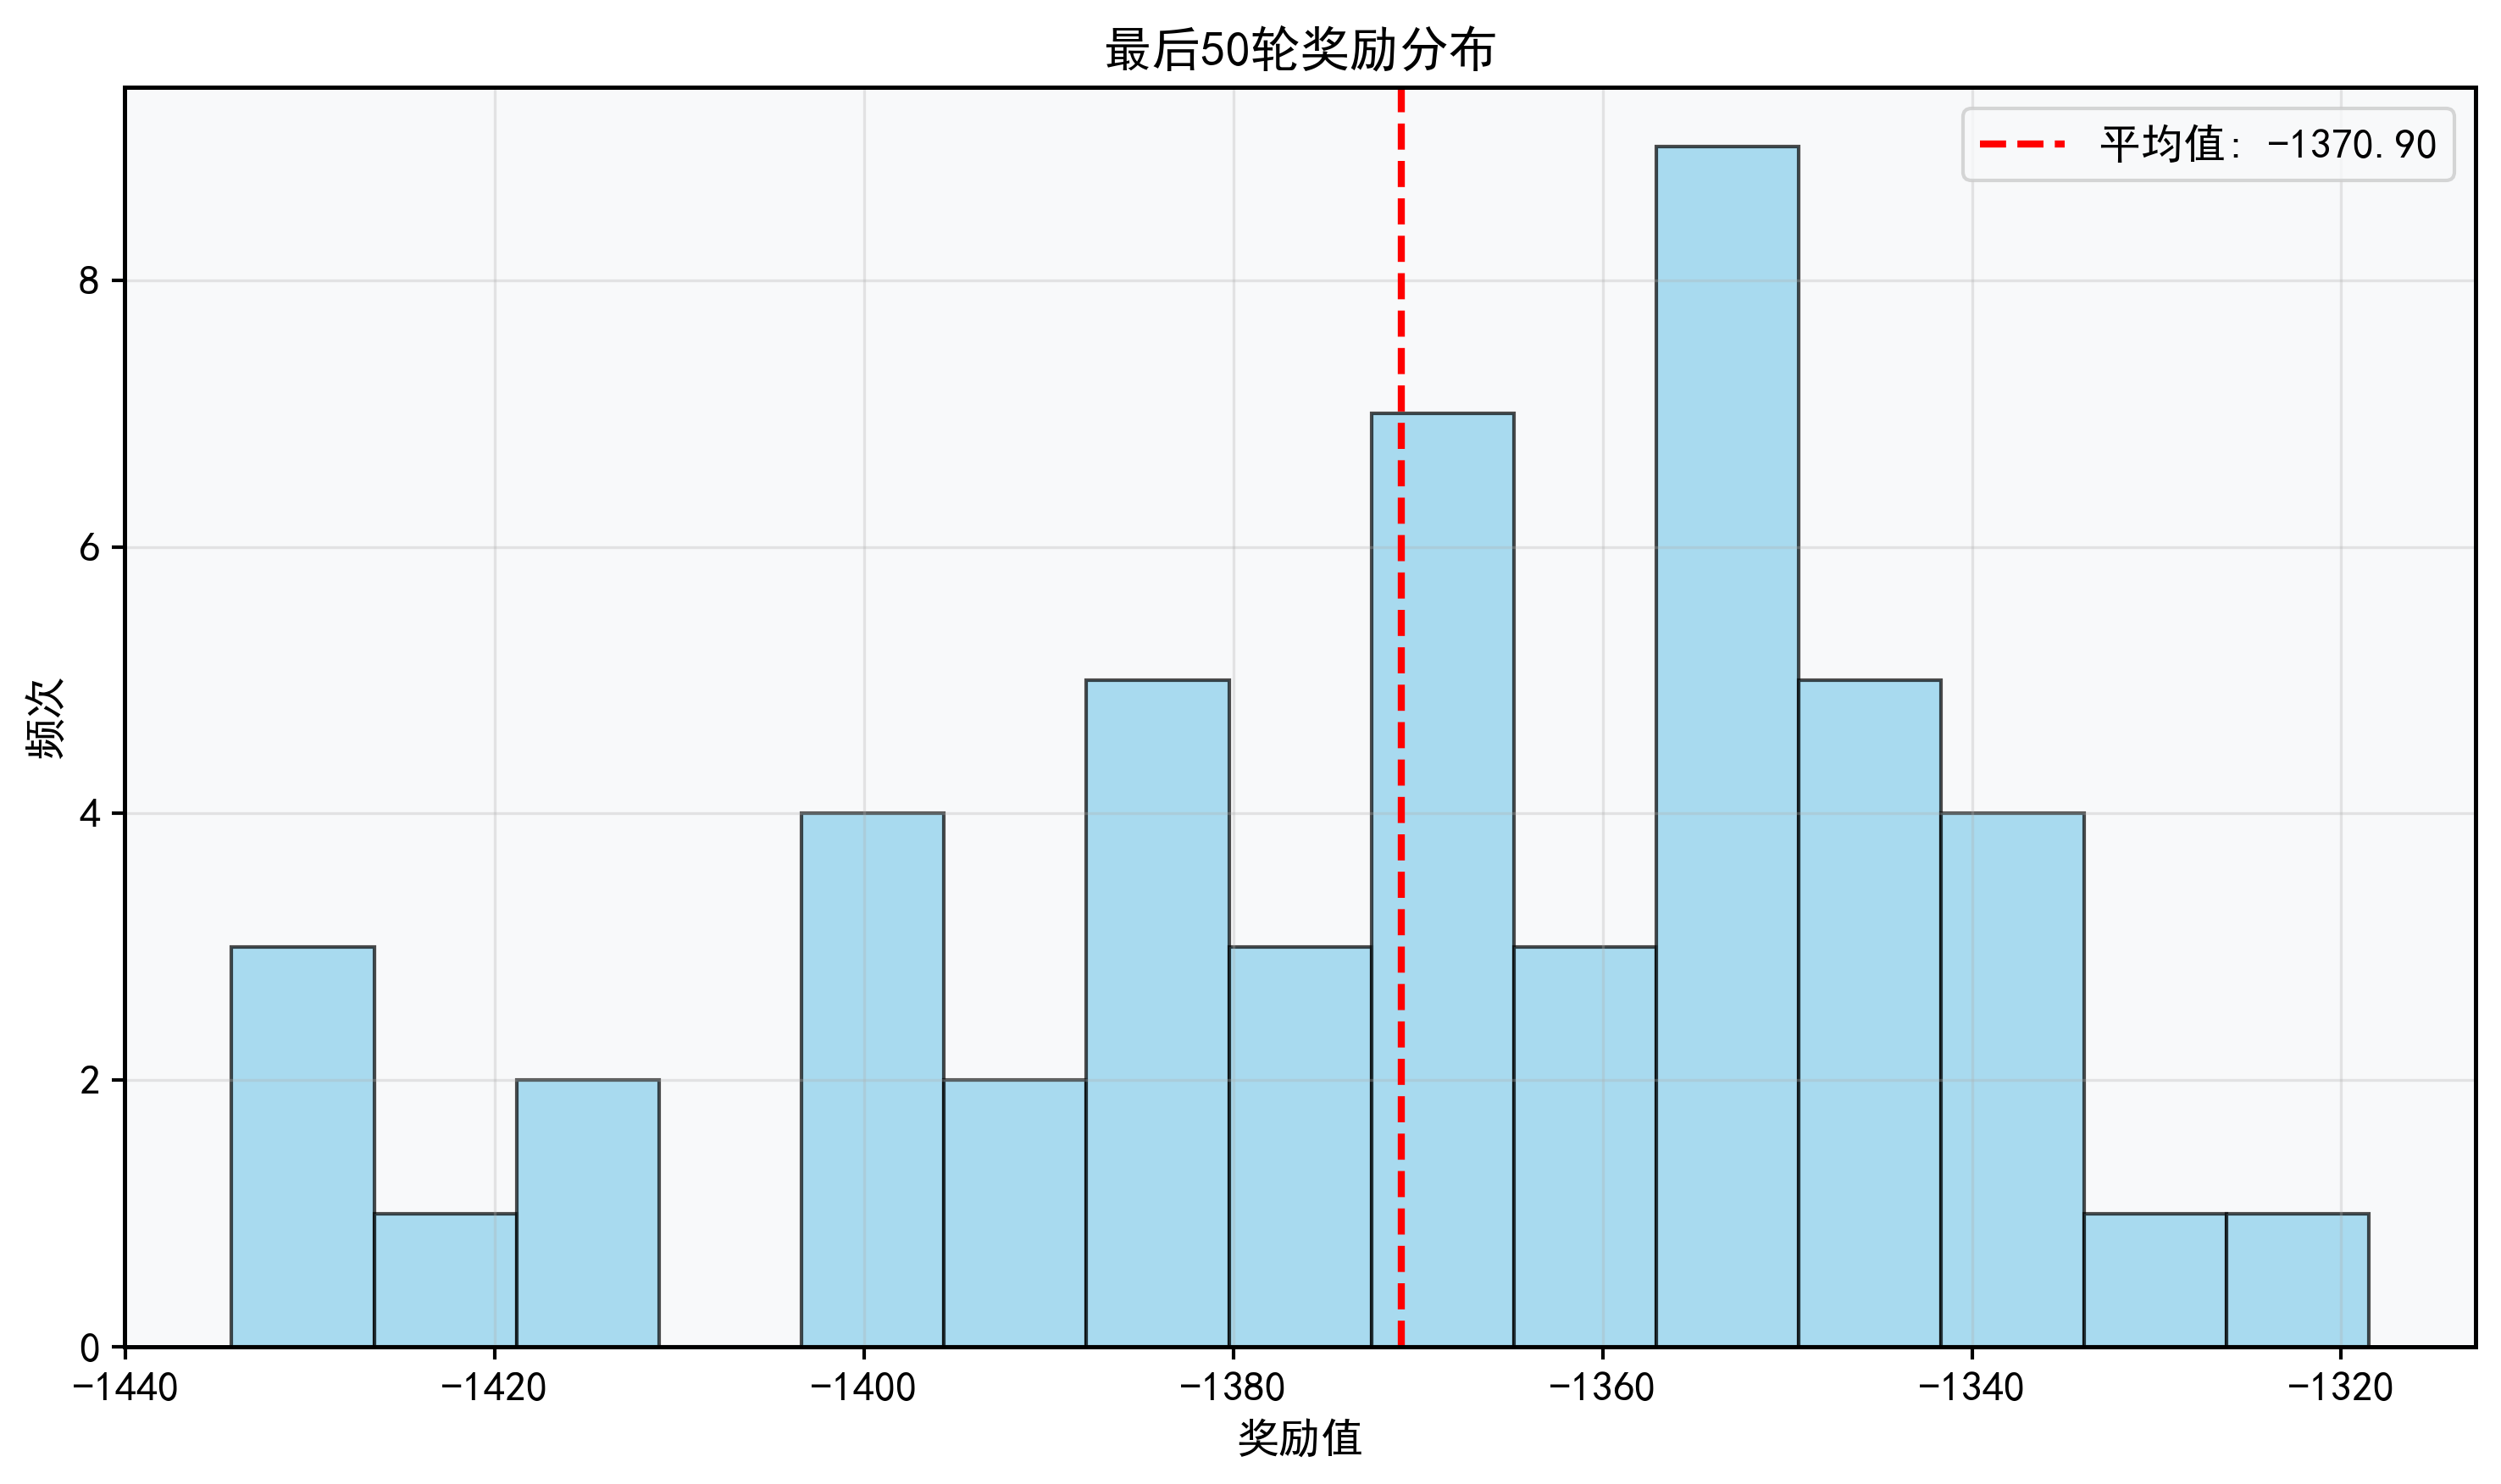

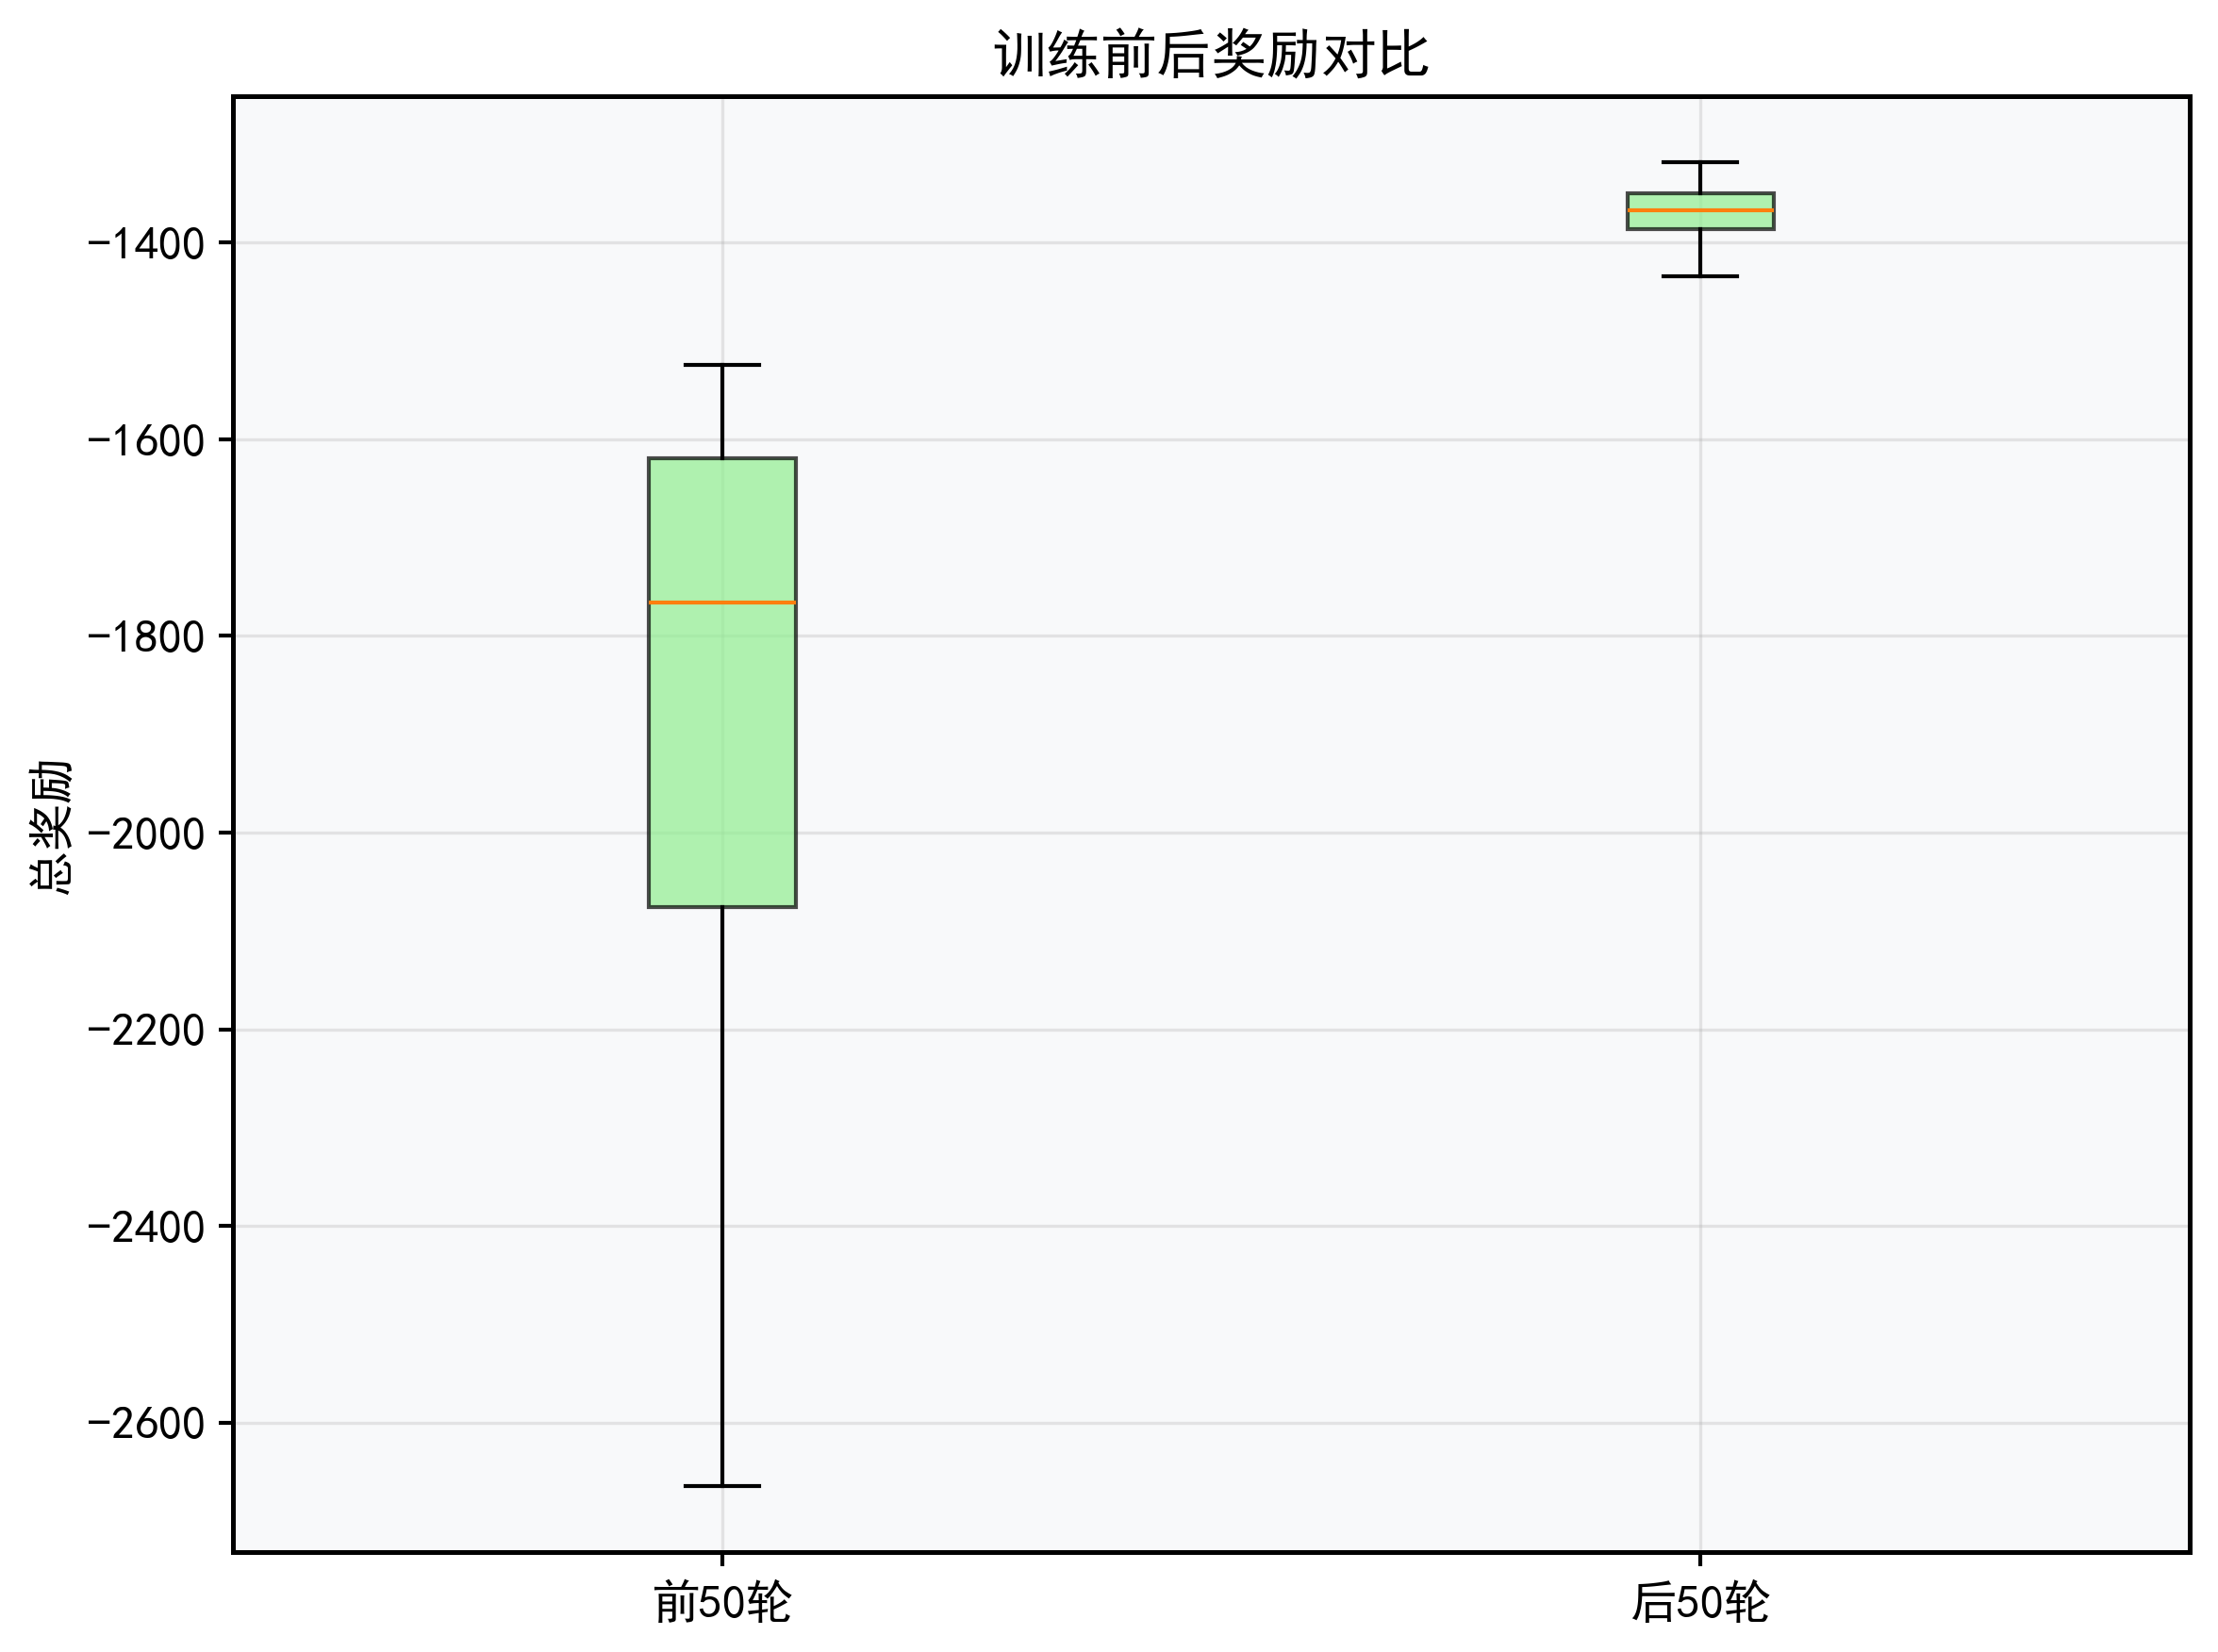

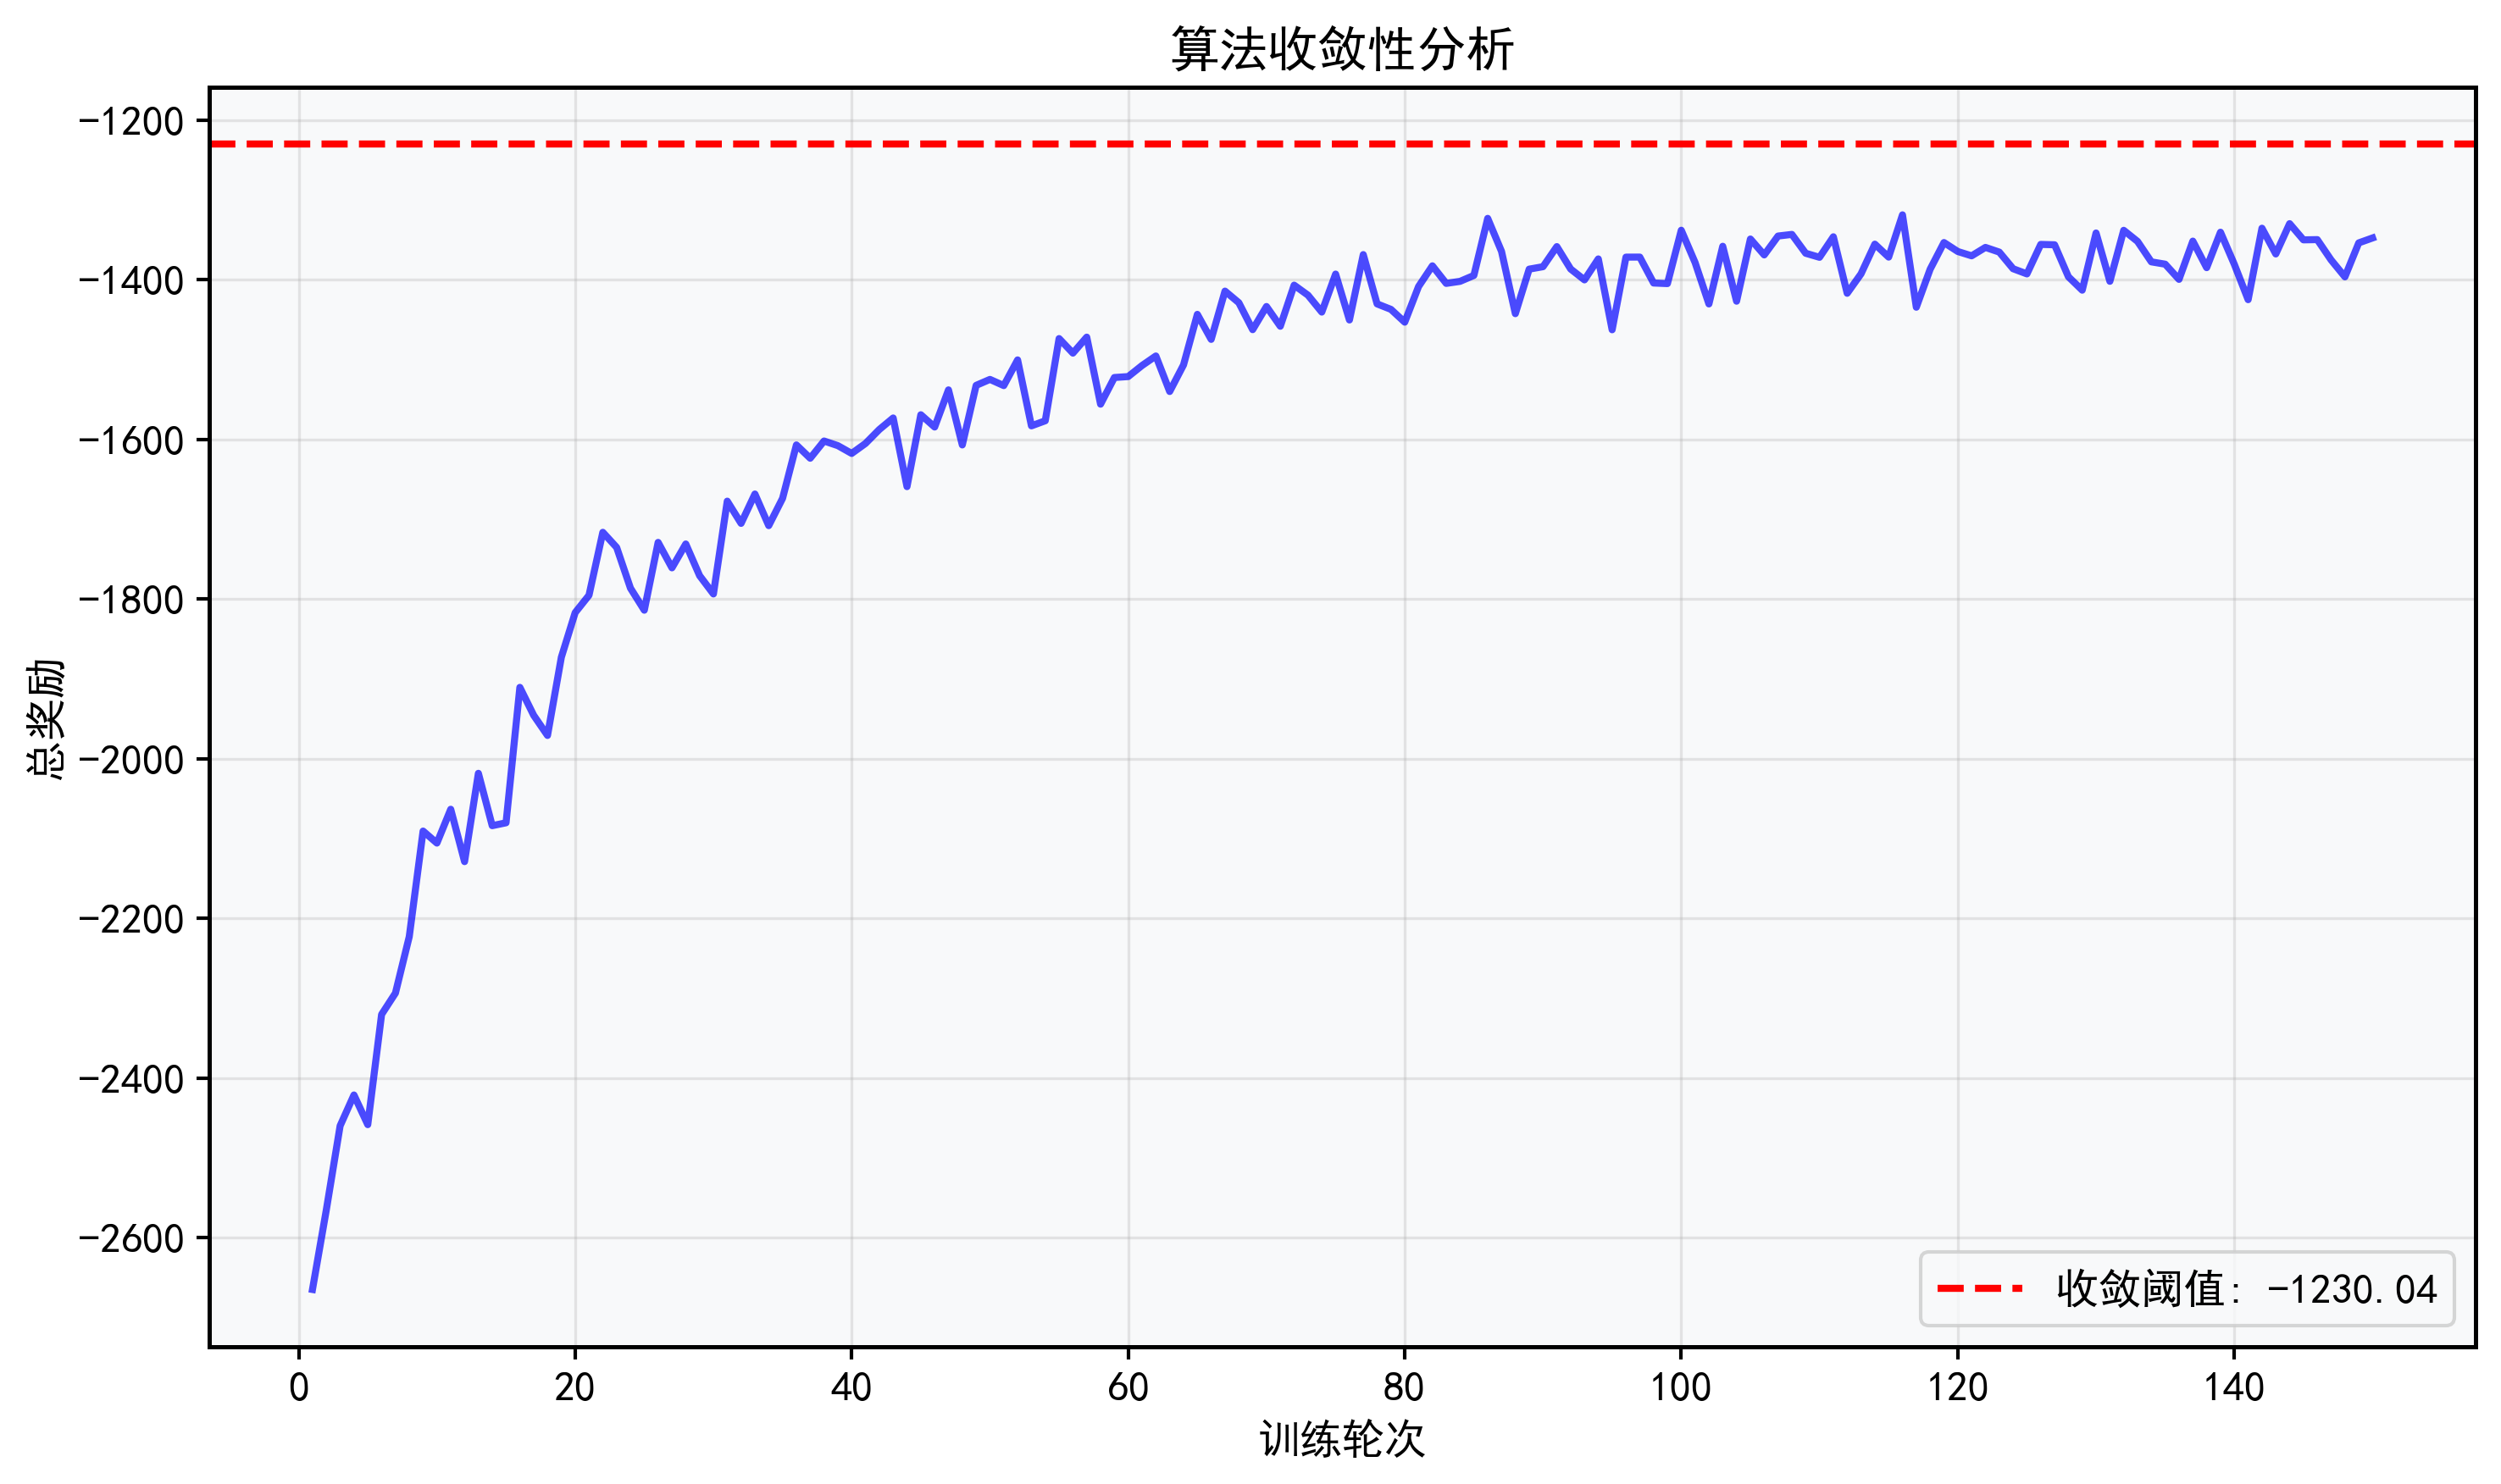


开始模型评估

评估结果汇总
智能体策略 | 平均奖励: -1349.46 ± 60.17 | 准确率: 95.80% | 平均耗时: 2630.0 | 平均切换次数: 71.6
全SWIR策略 | 准确率: 31.34% | 耗时: 200.0
全Raman策略 | 准确率: 100.00% | 耗时: 3000.0


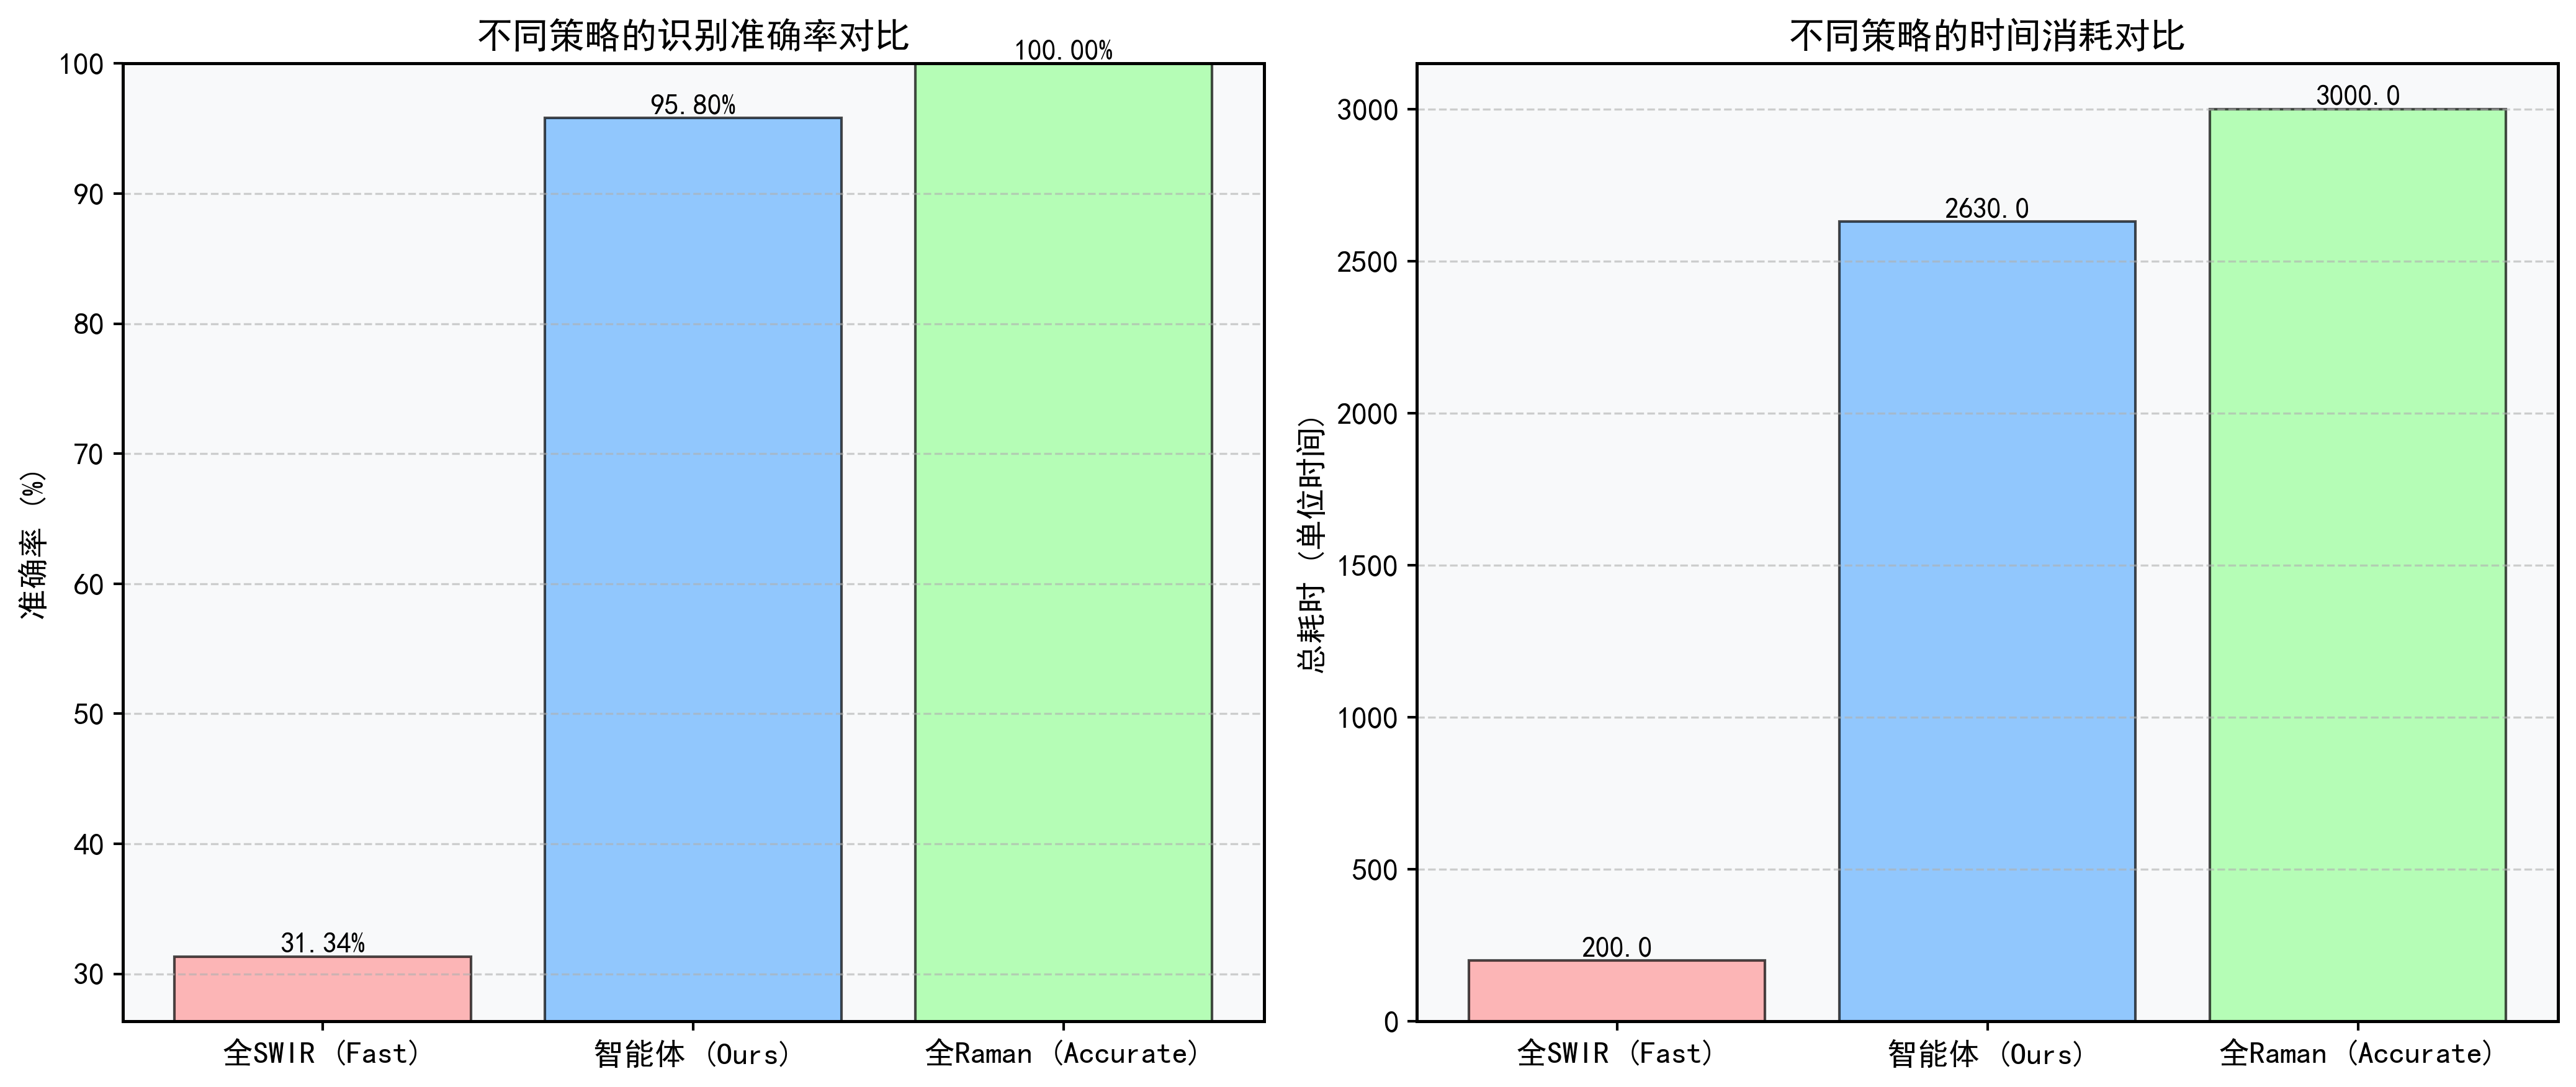


训练统计摘要
总训练轮数: 150
平均奖励 (全部轮次): -1559.25
平均奖励 (最后50轮): -1370.90
最佳单轮奖励: -1318.51 (第 116 轮)

开始高级评估，收集决策数据...
已完成 50/100 轮
已完成 100/100 轮

核心指标对比
智能体 | 准确率: 94.39% | 平均耗时: 2587.0 | 平均切换次数: 74.0
全SWIR | 准确率: 31.34% | 耗时: 200.0
全Raman | 准确率: 100.00% | 耗时: 3000.0


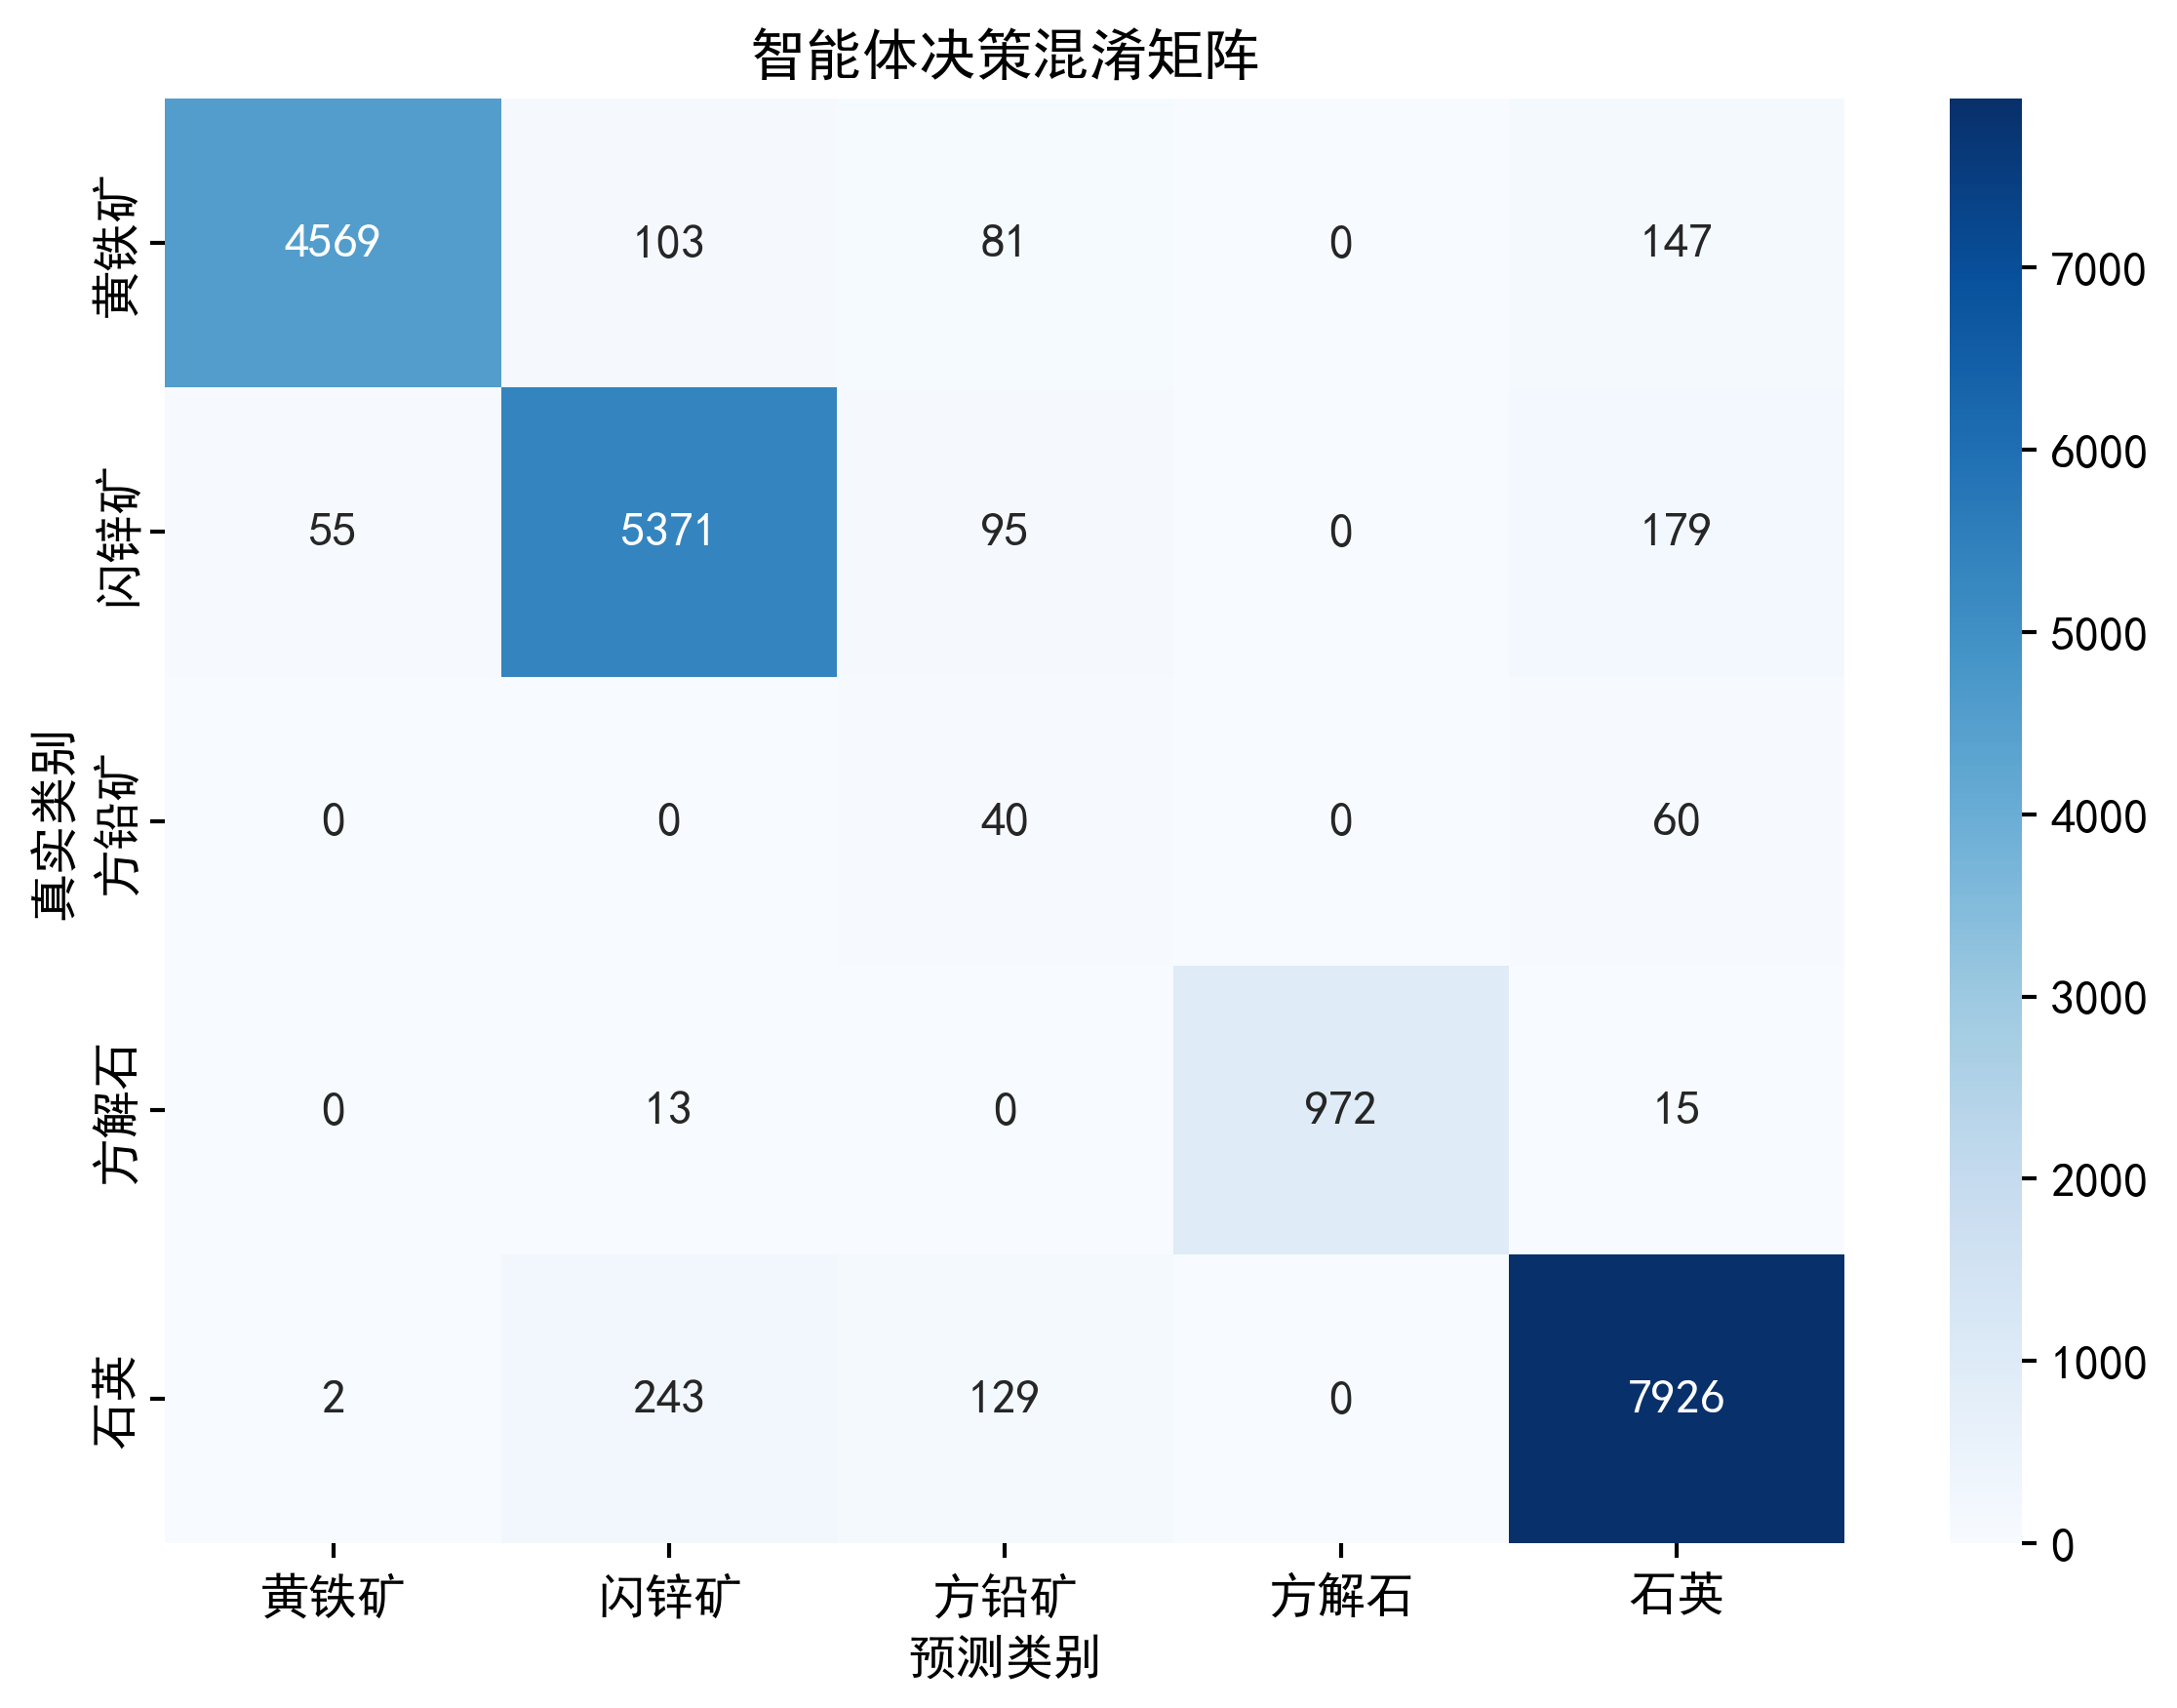

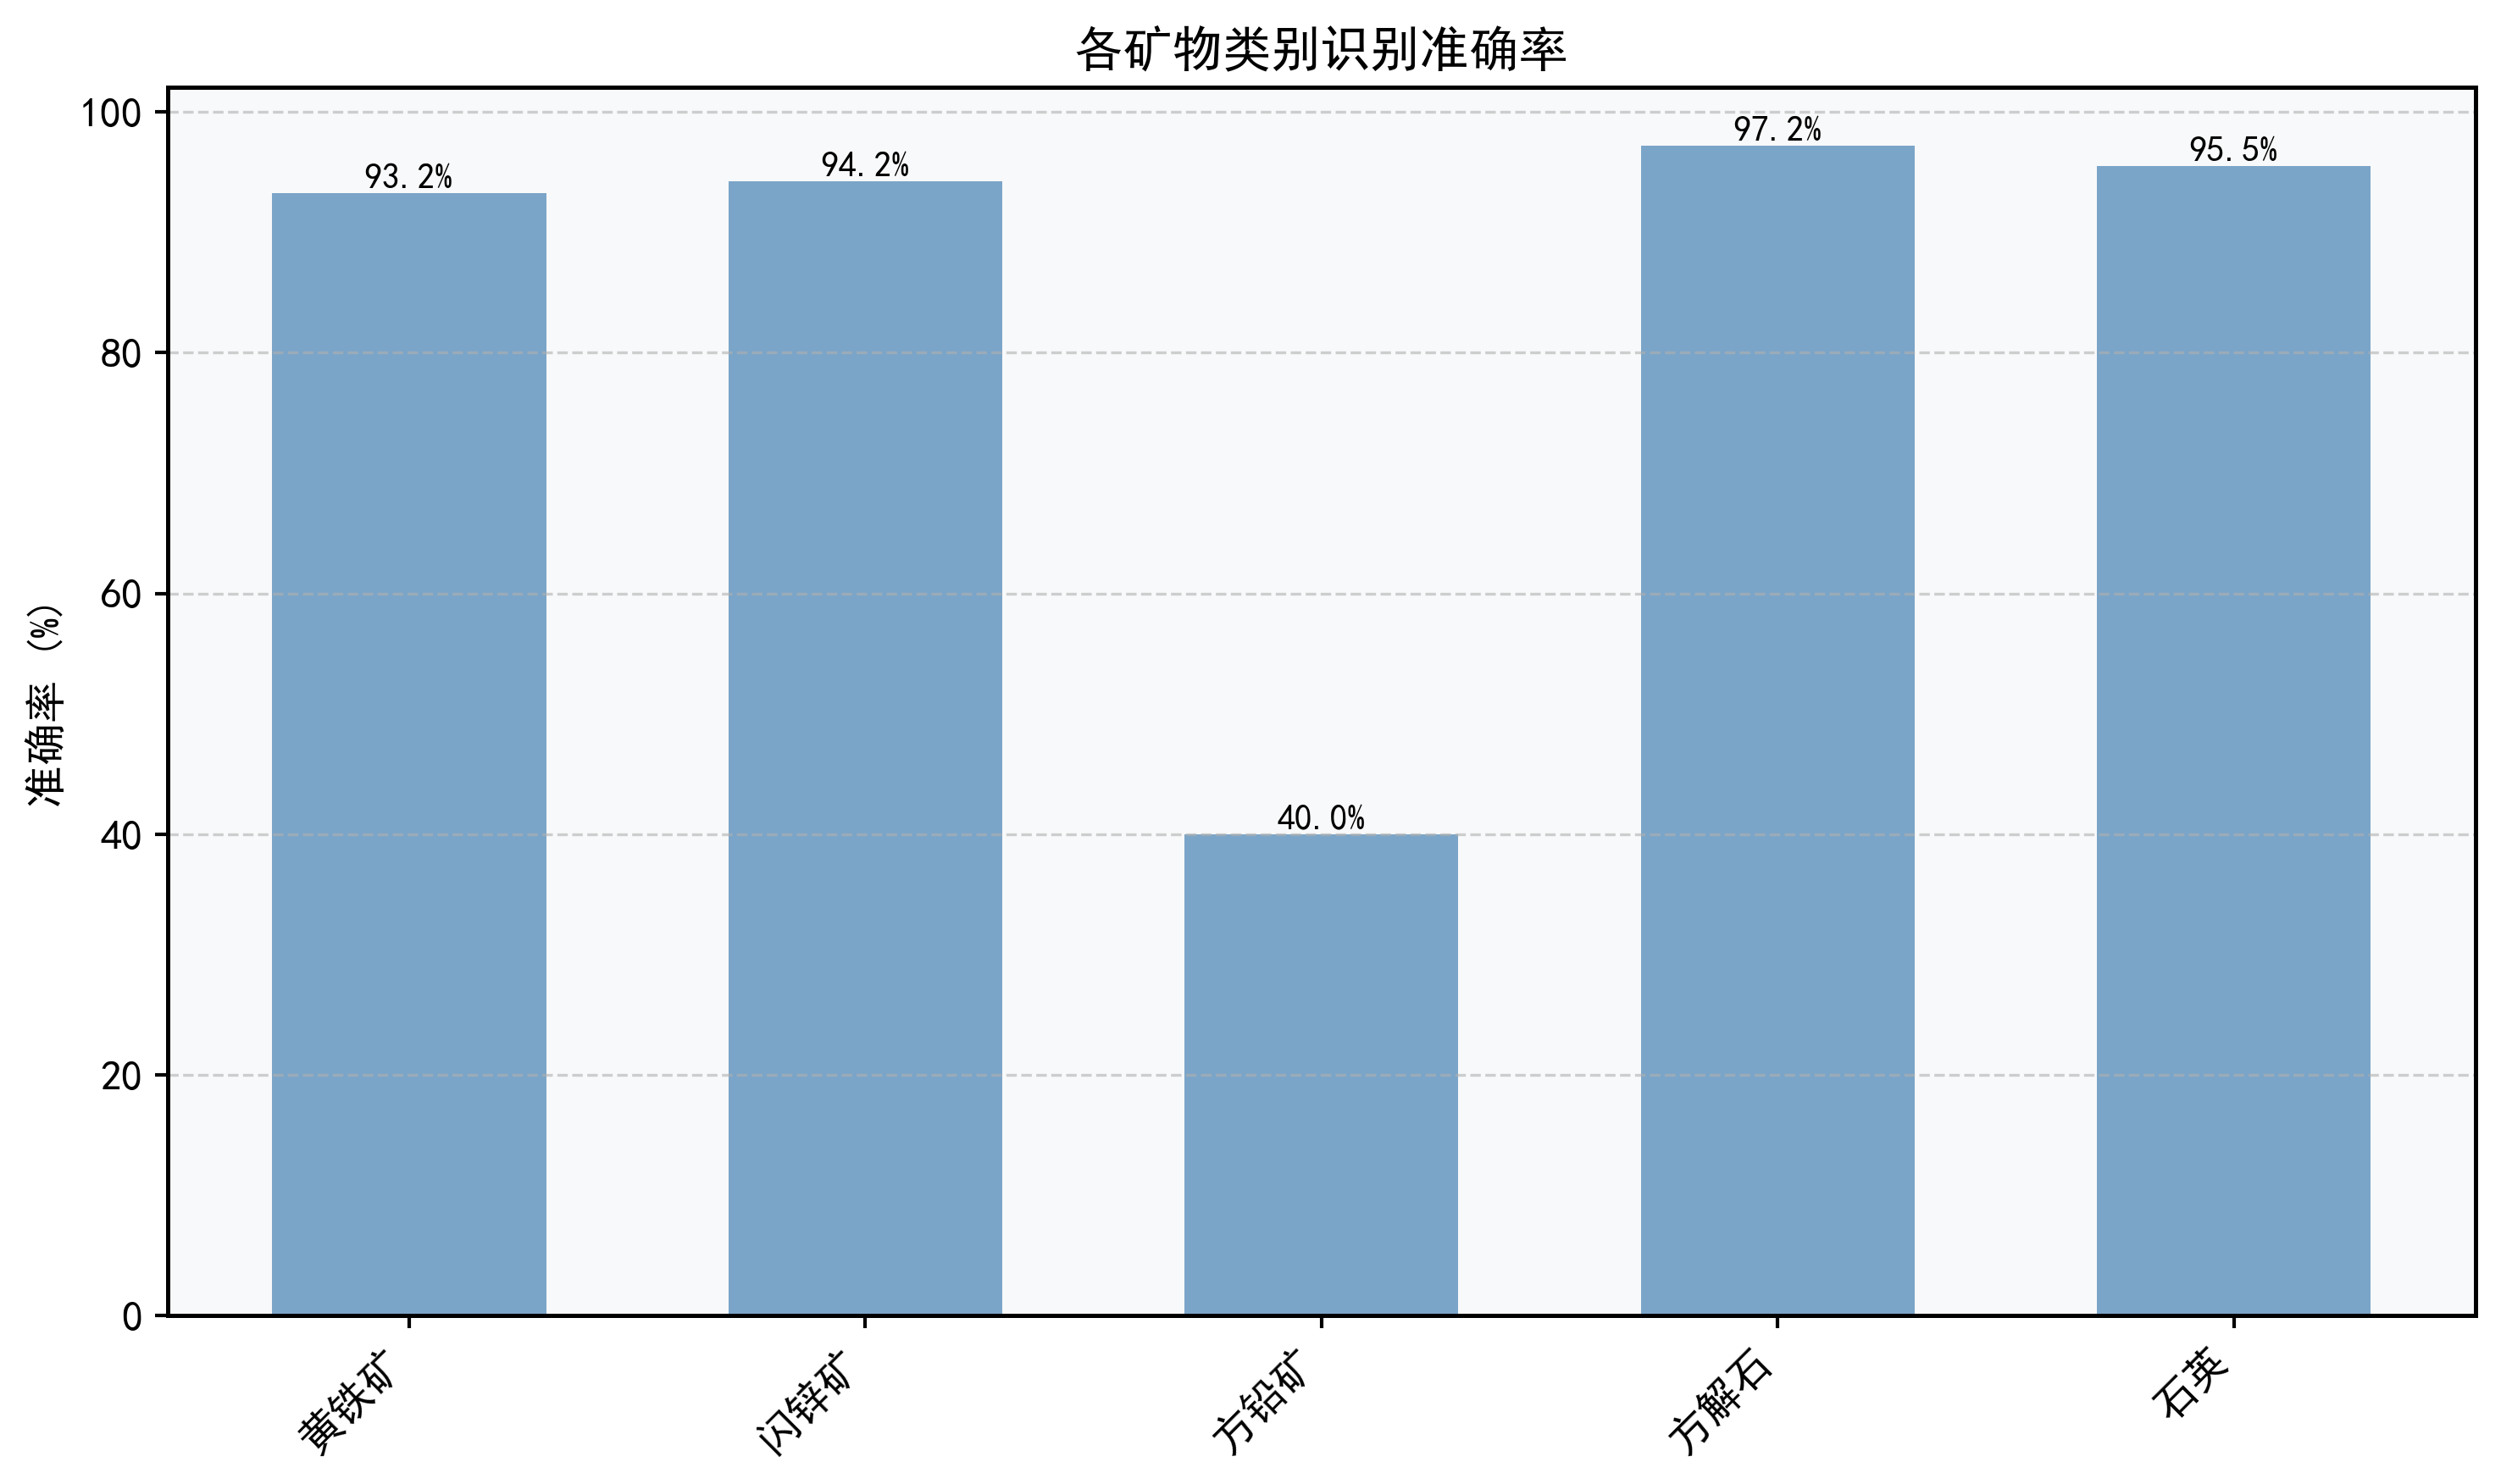

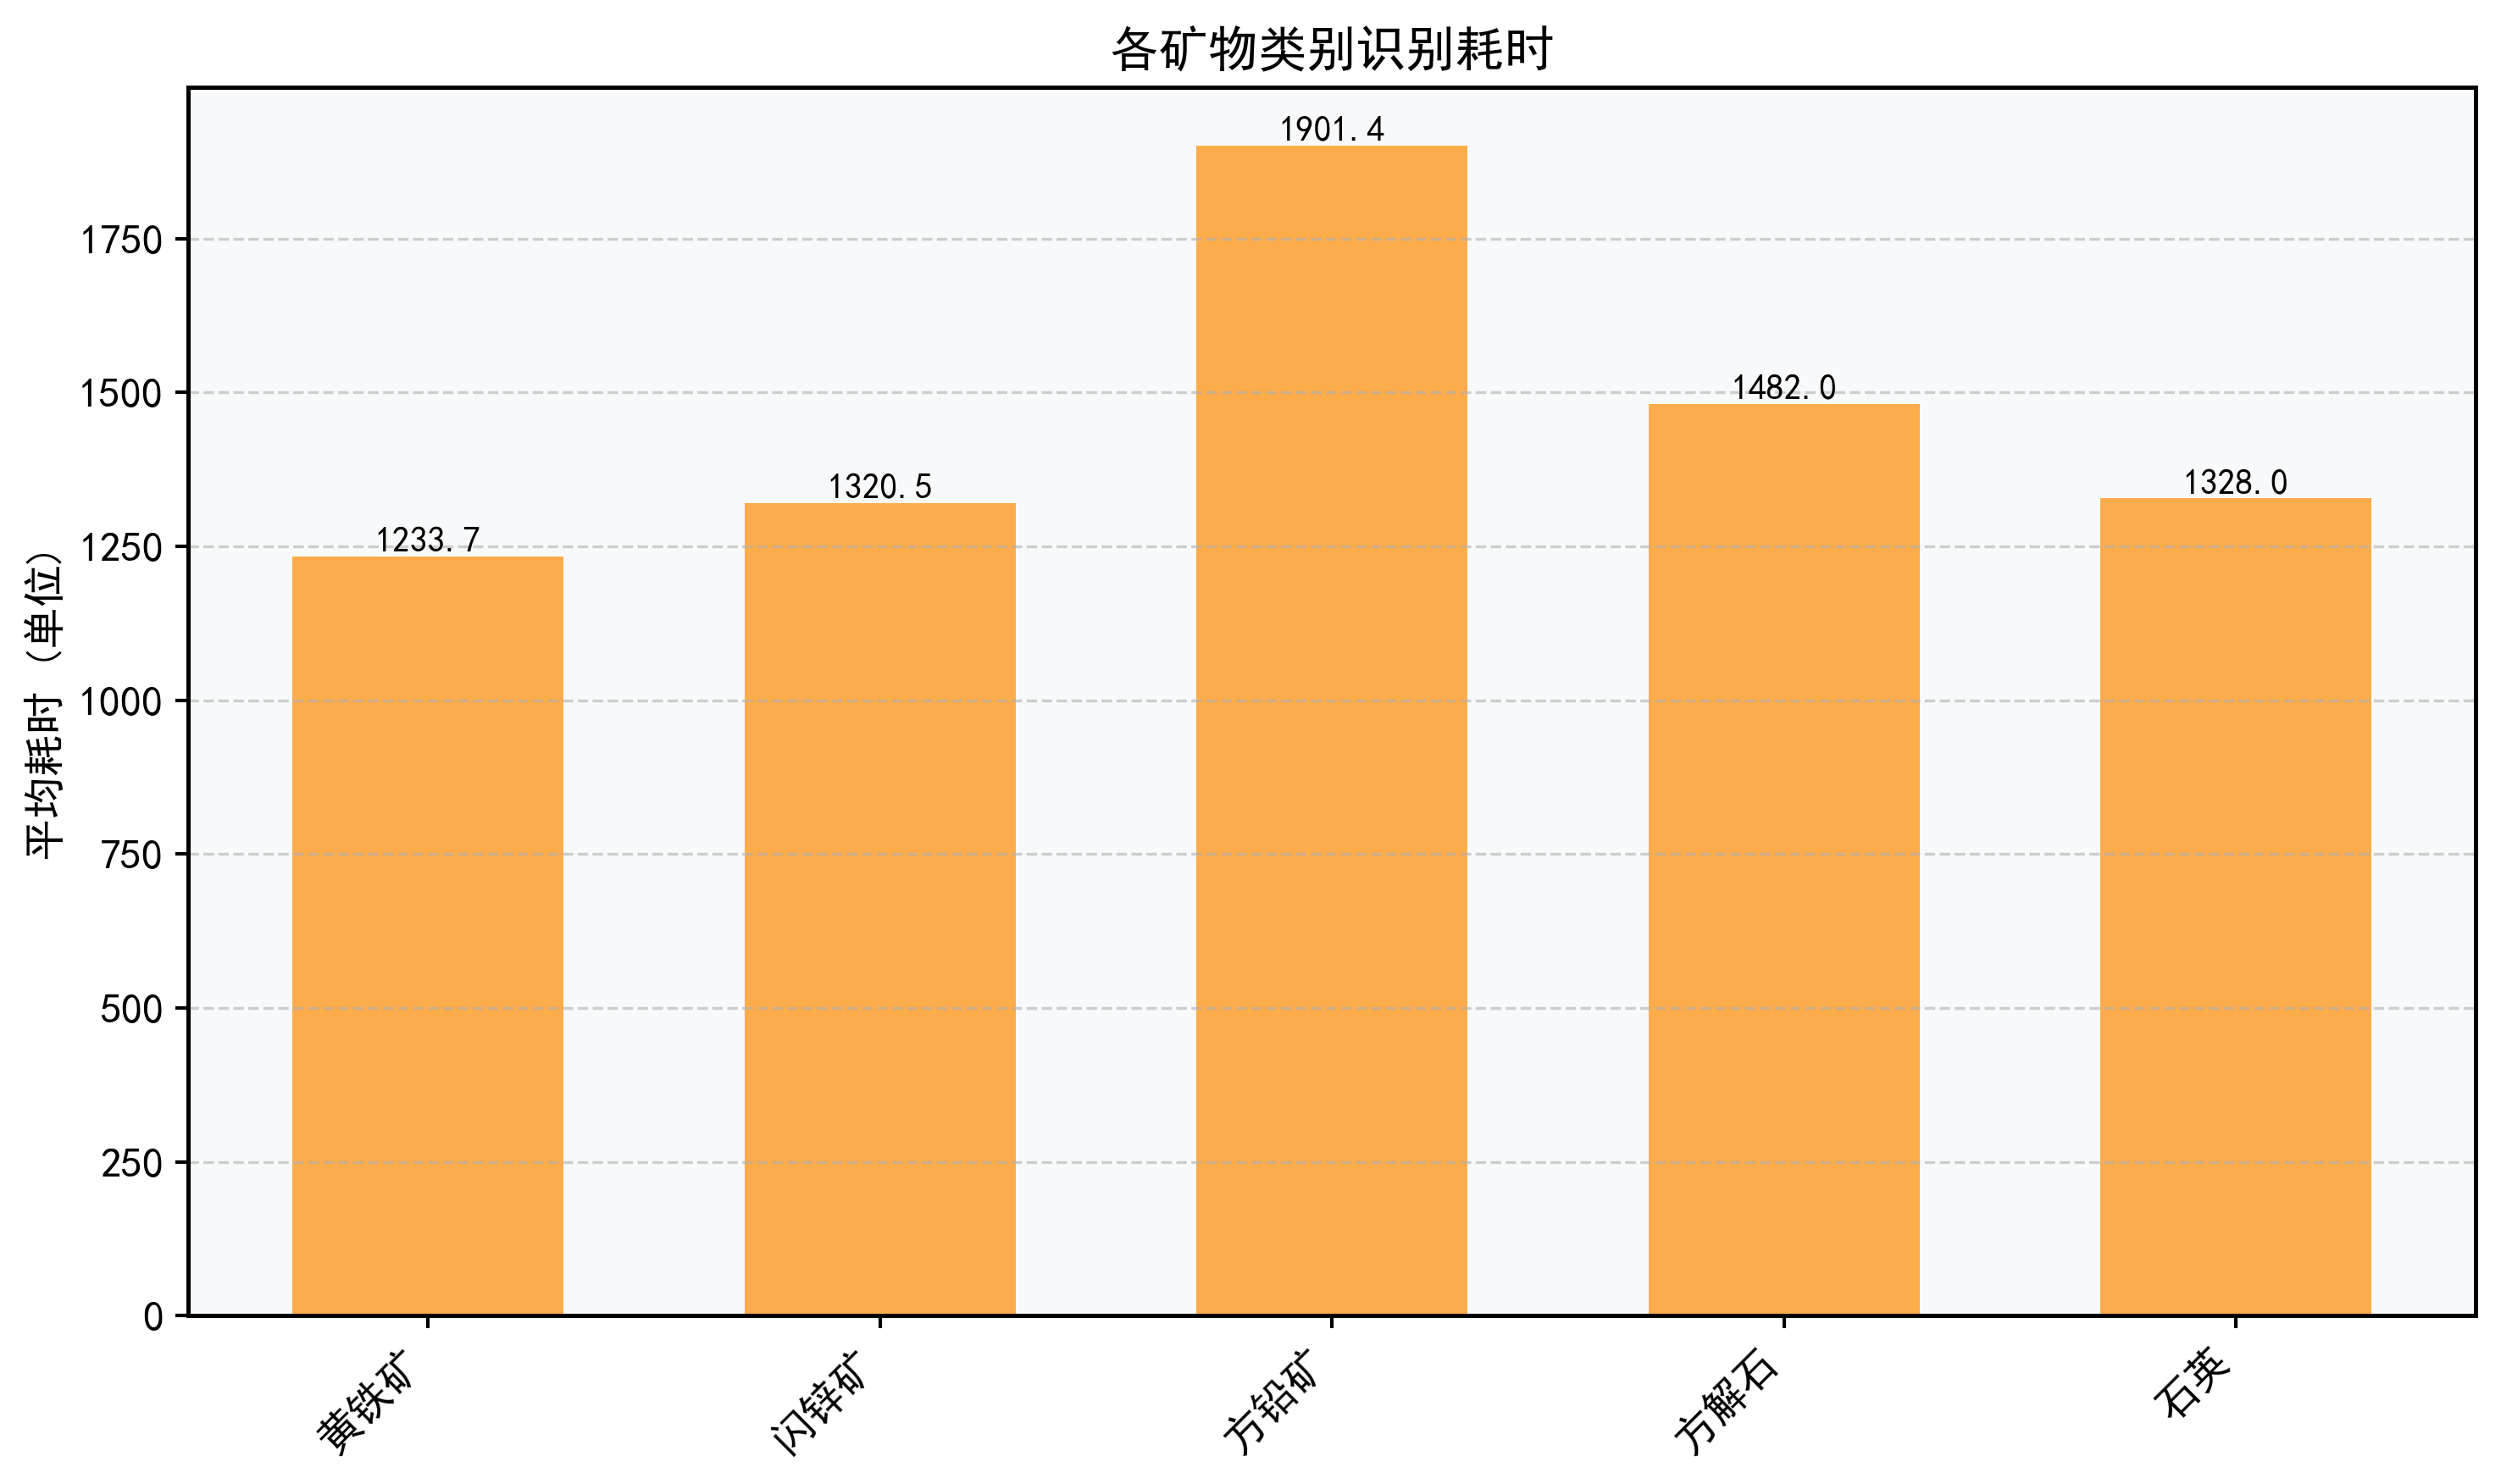

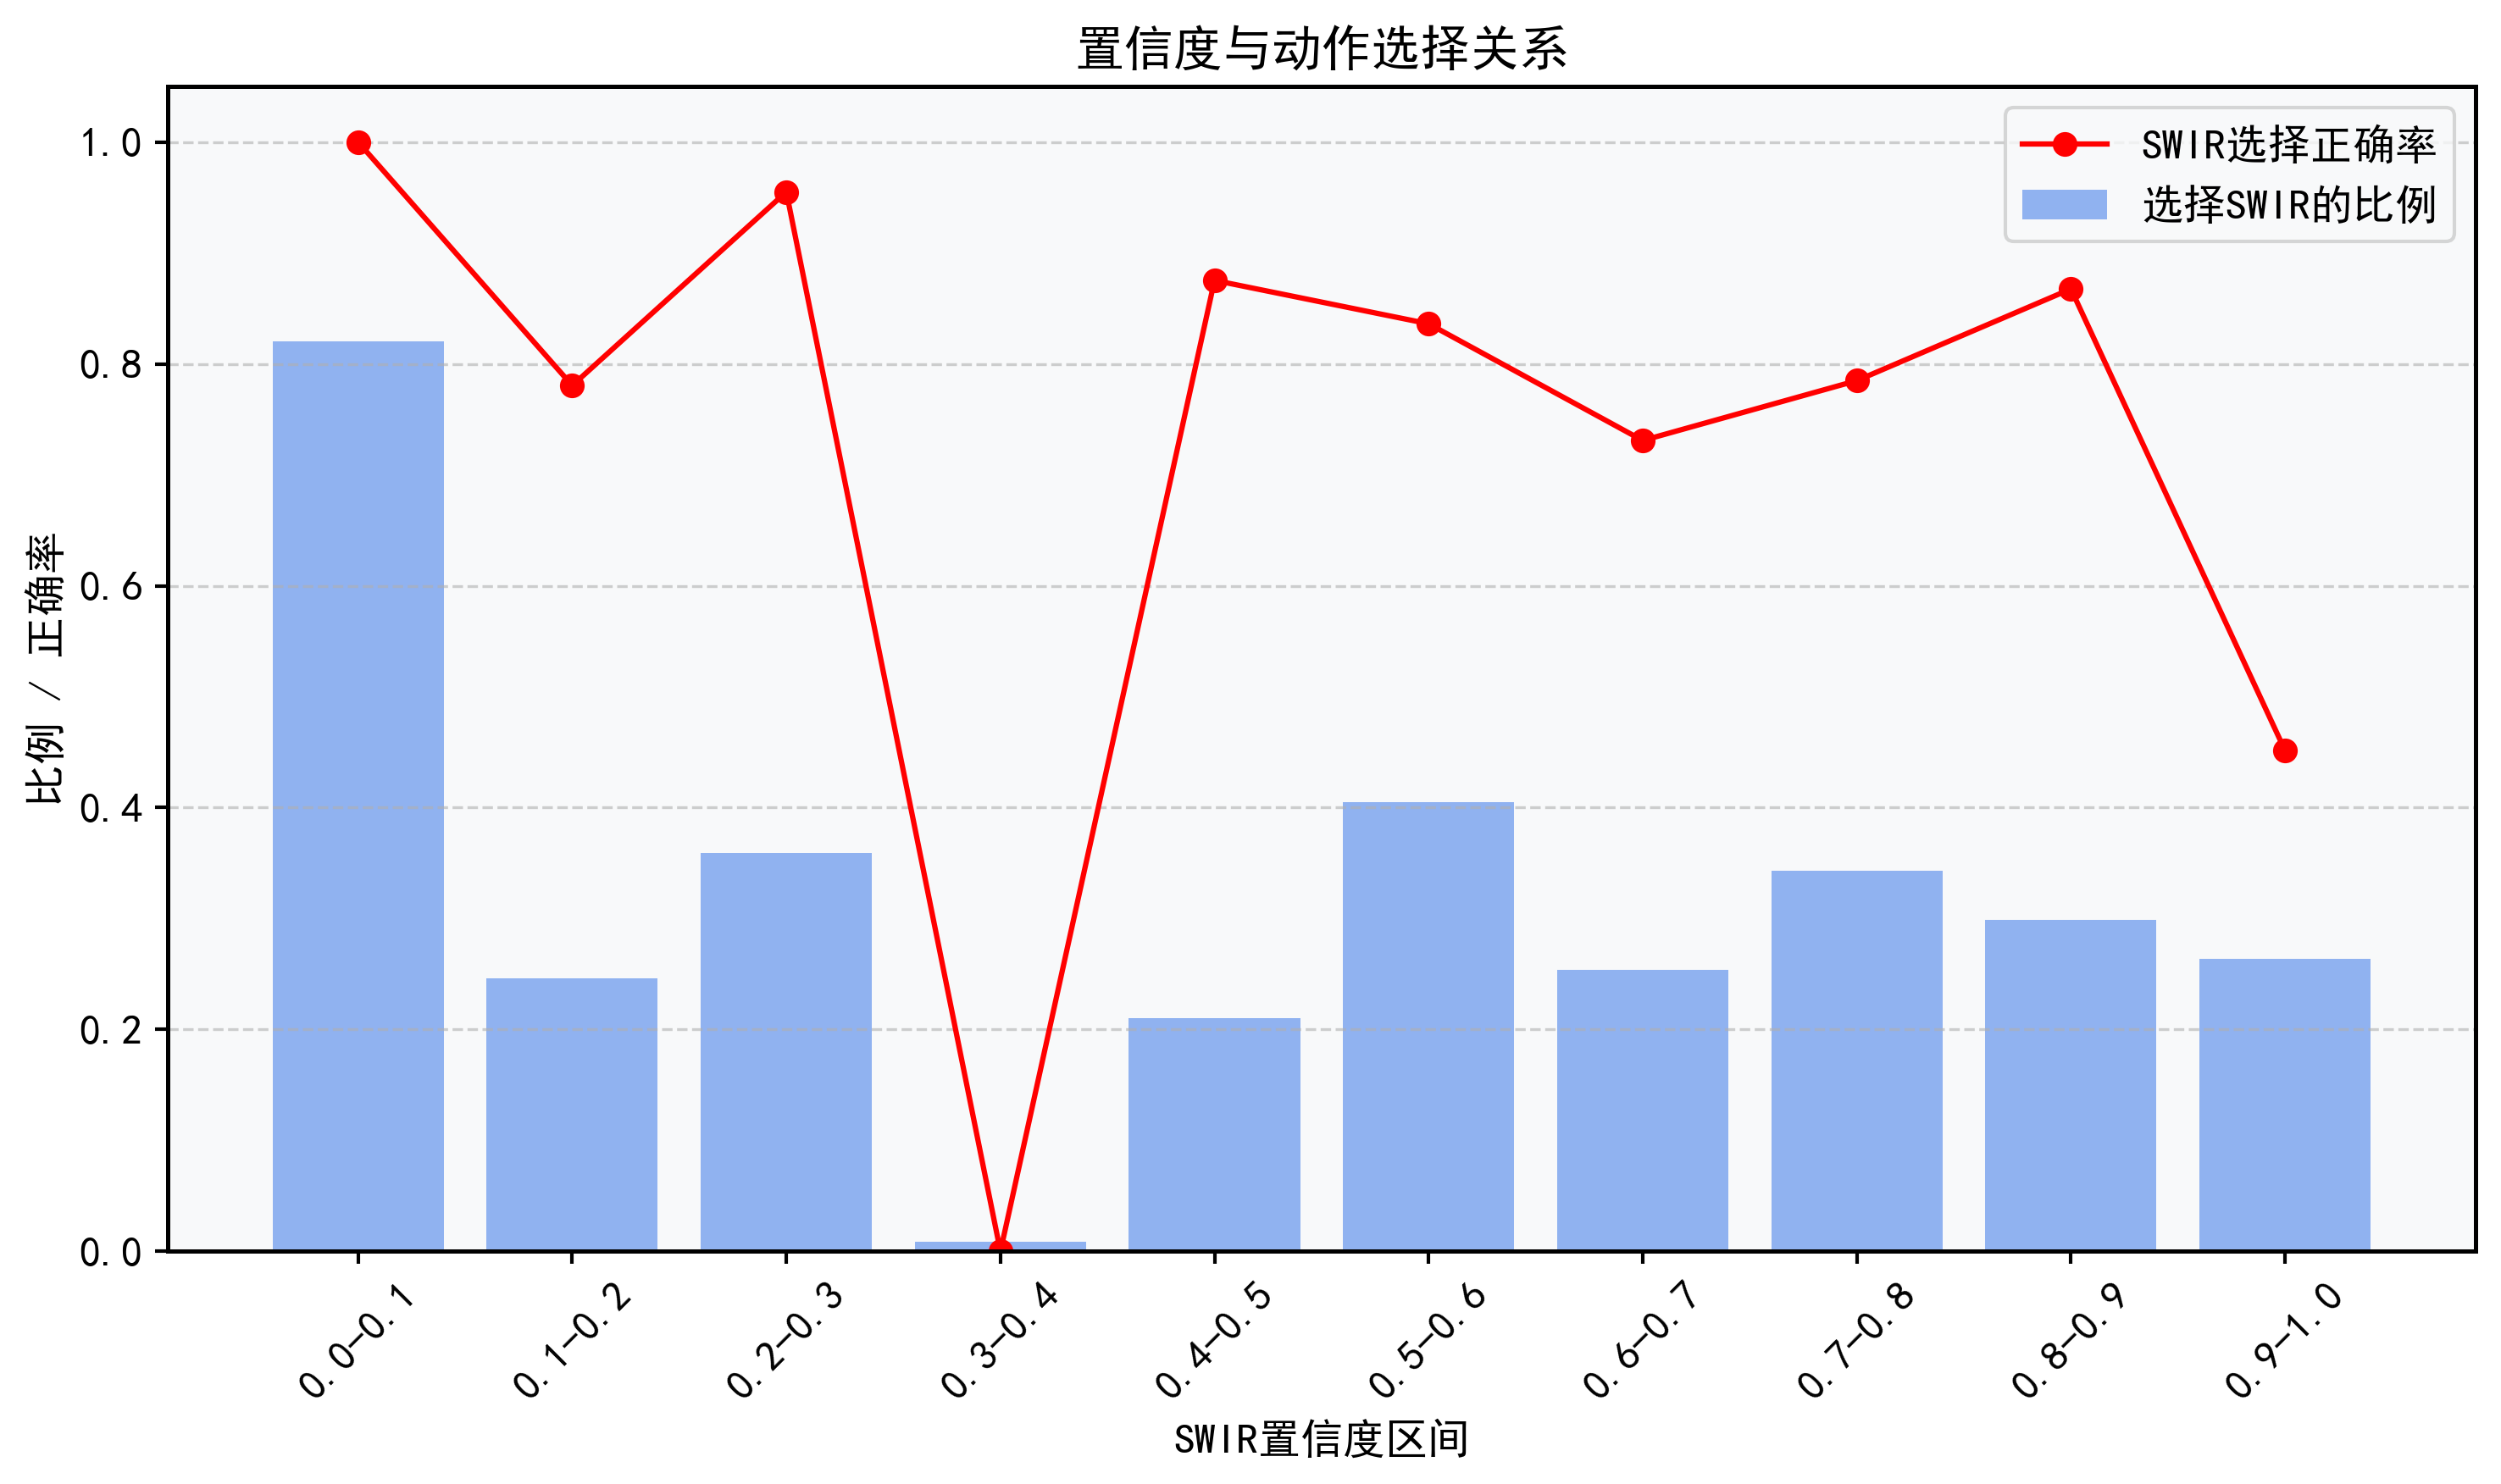

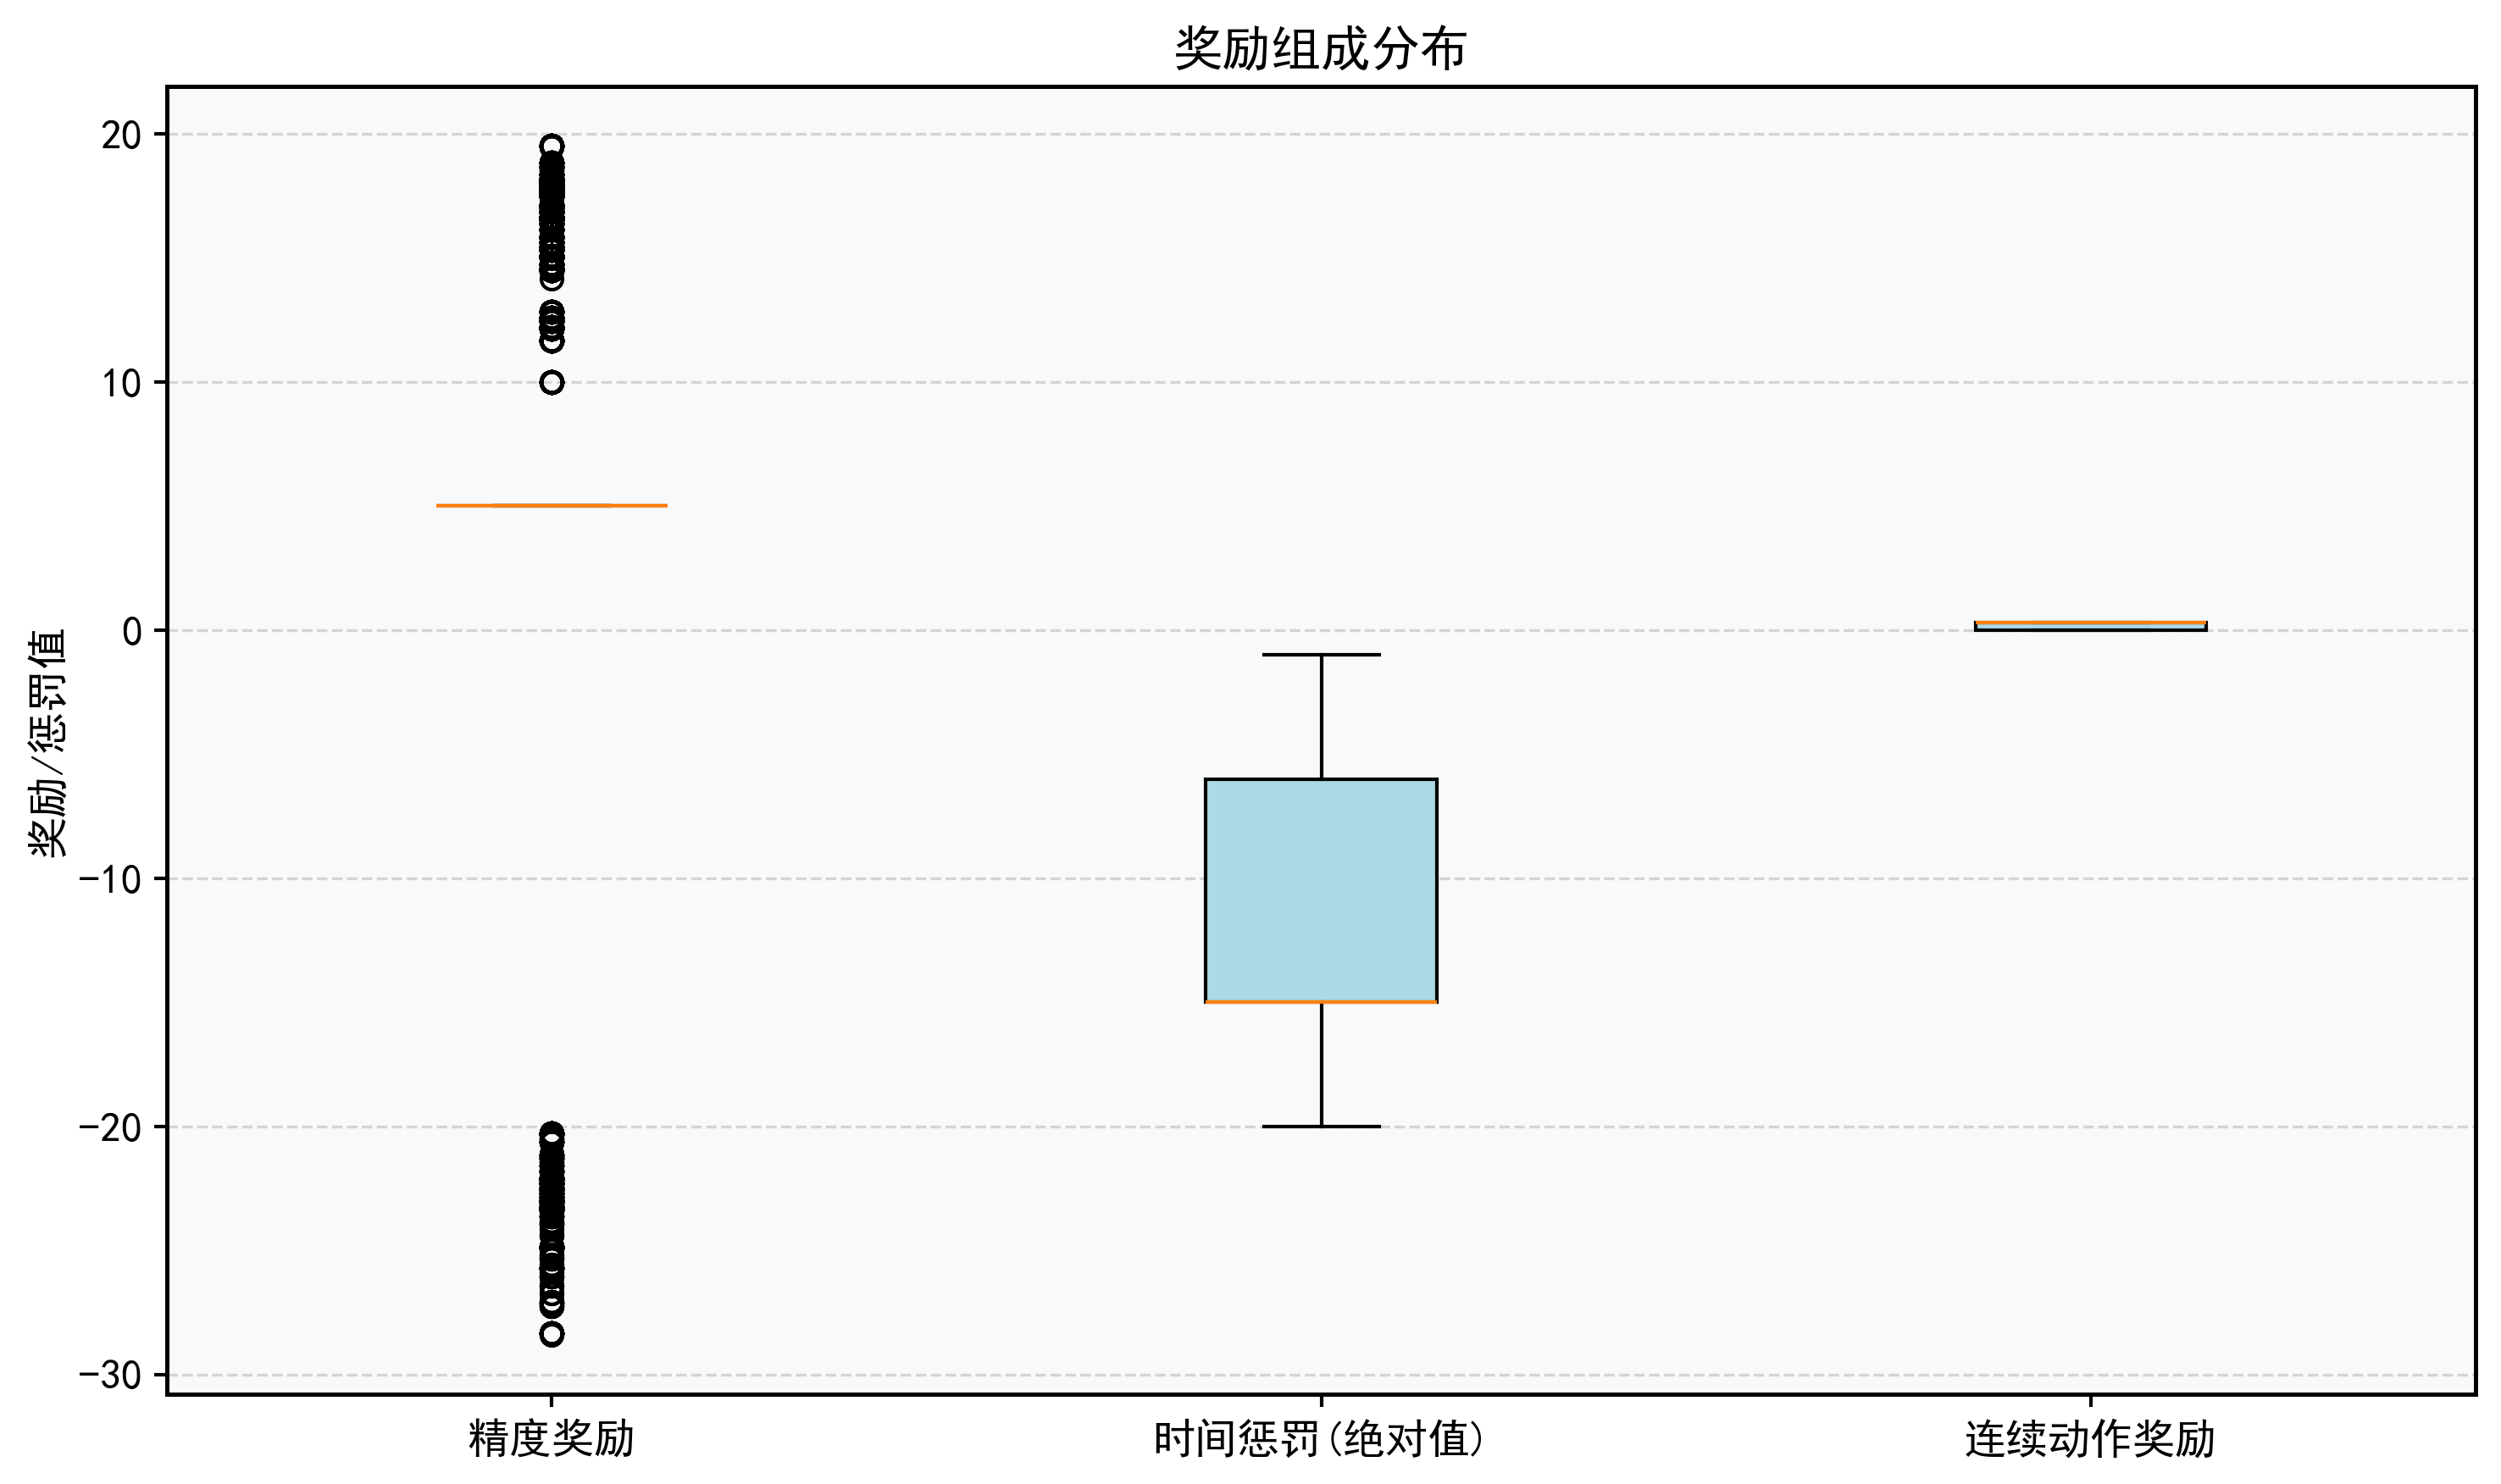

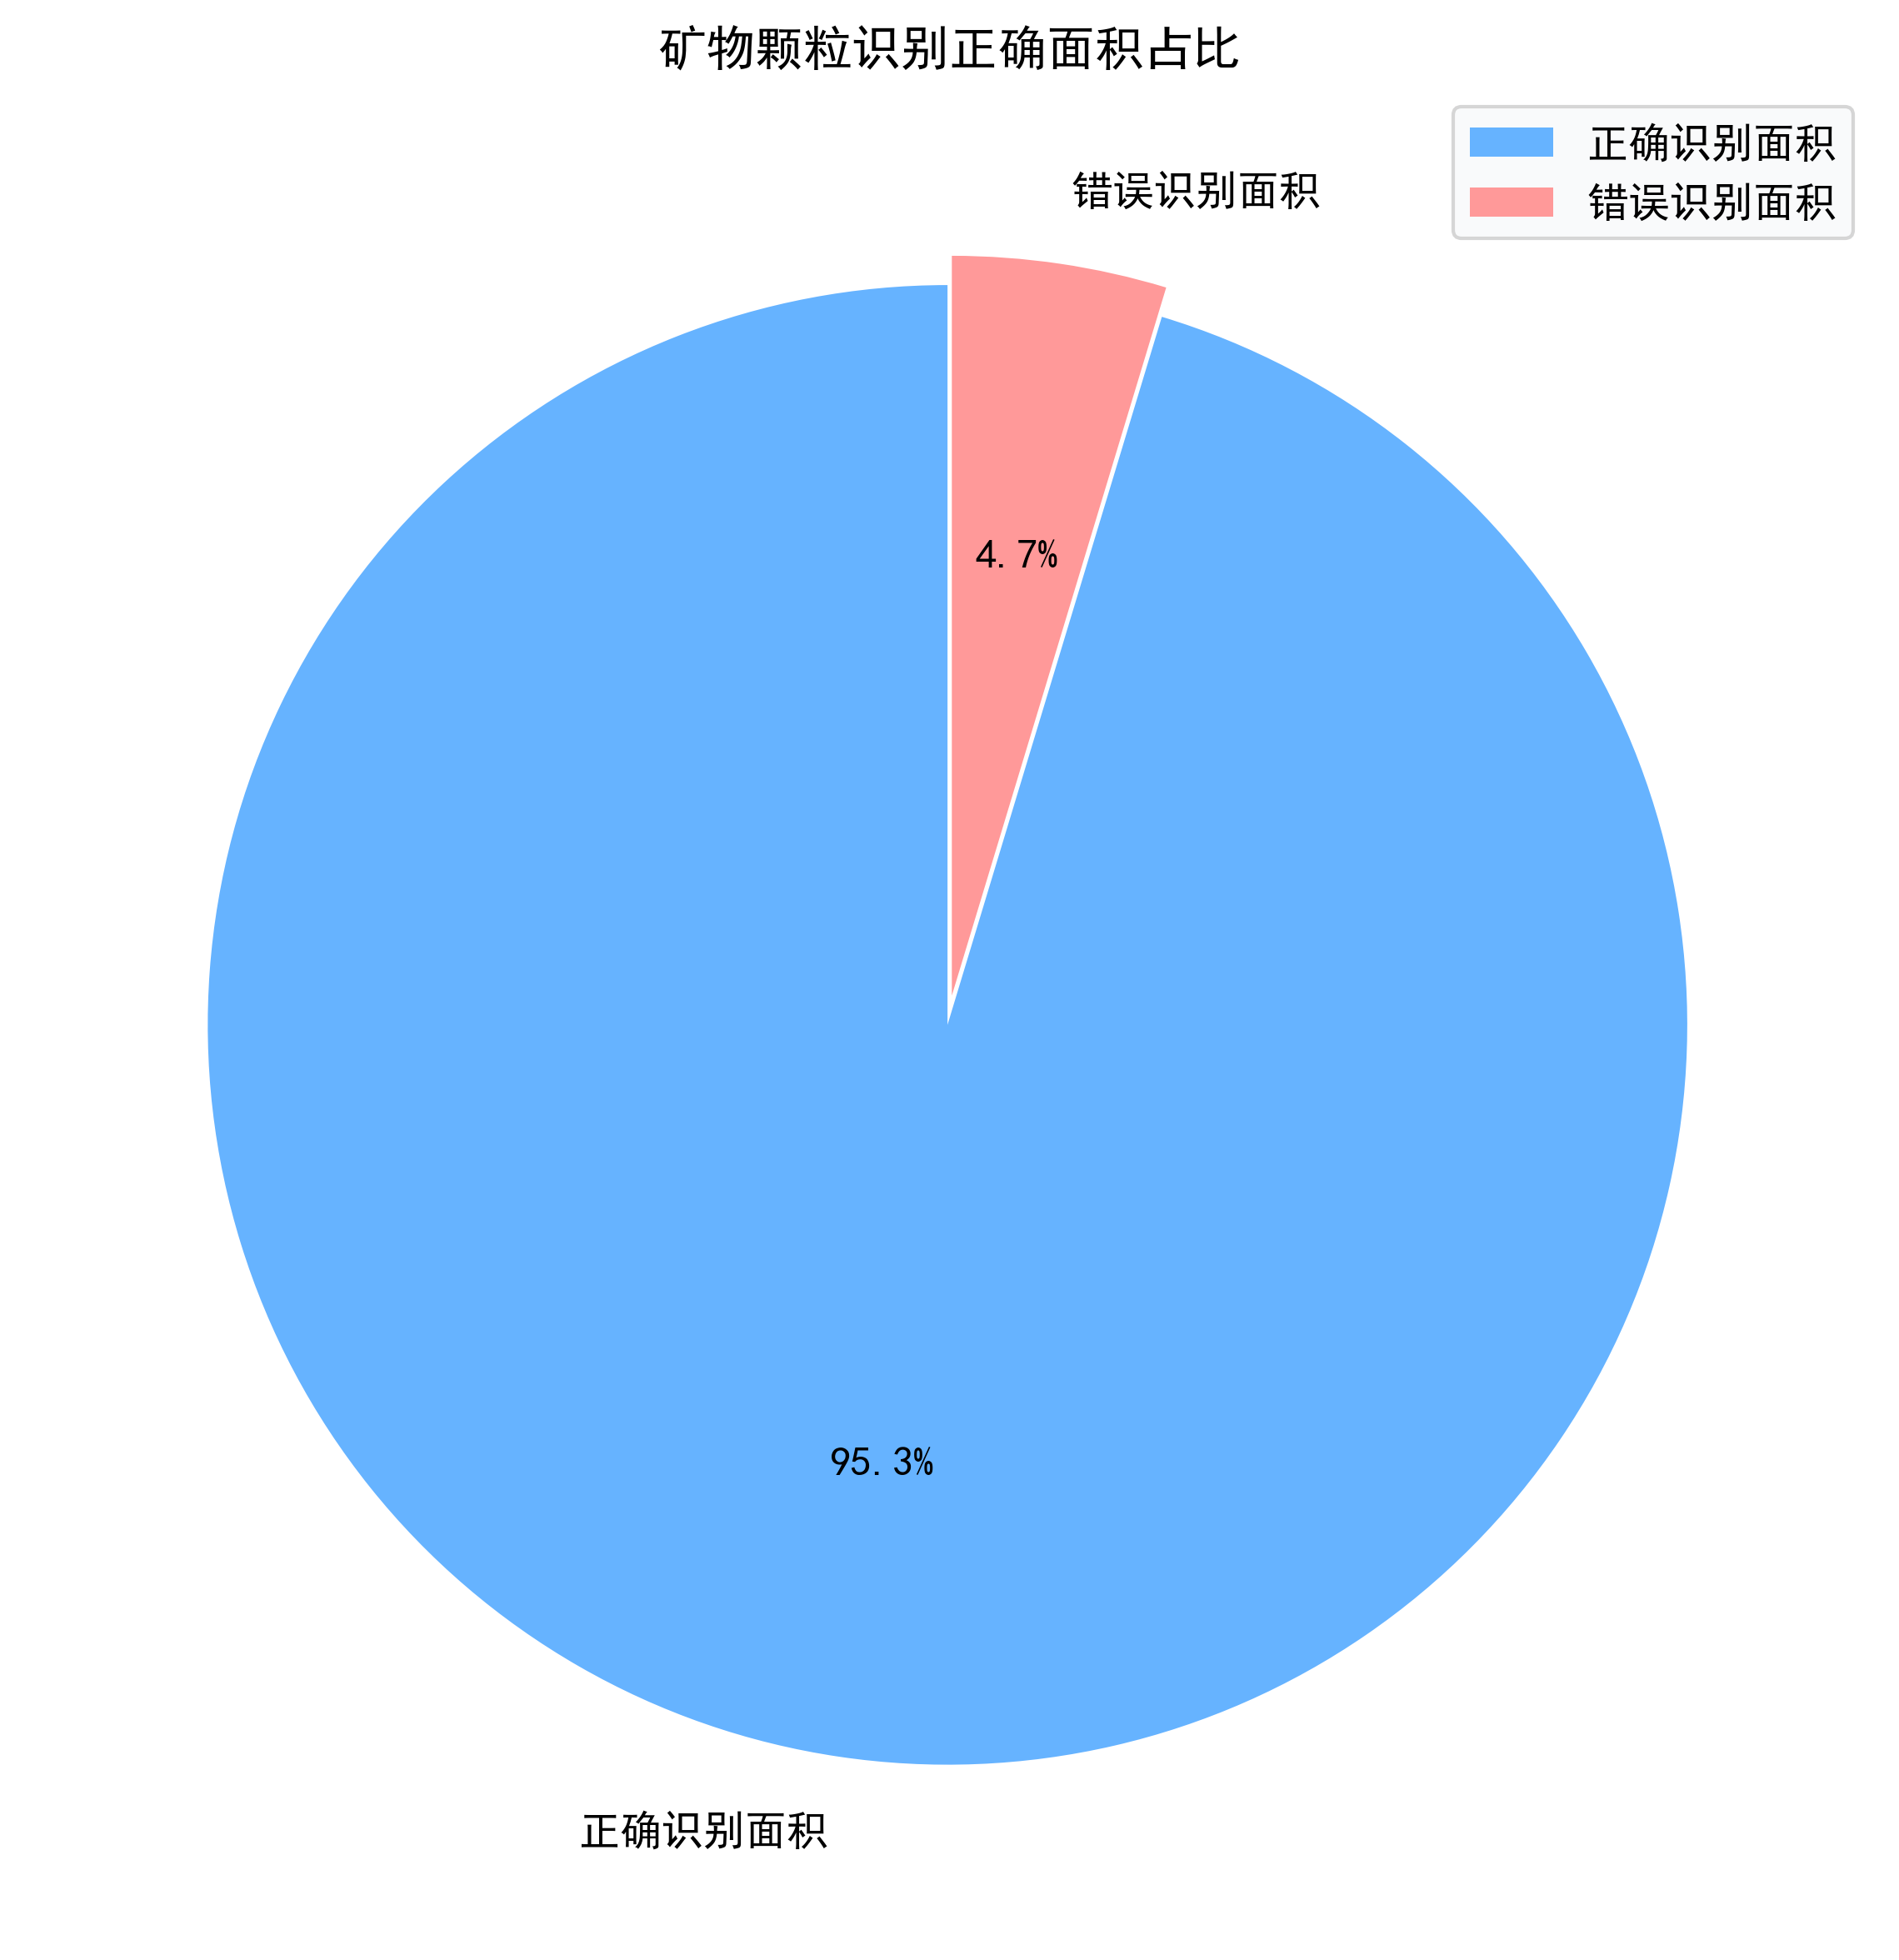

正确识别面积占比: 95.32%

所有分析结果已保存至 ./output

所有分析完成，结果已保存至 ./output 目录！


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import gym
from gym import spaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib
from sklearn.preprocessing import StandardScaler
import warnings

# 基础配置
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei', 'sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12

# 残差块定义 - 构建深度策略网络的基础模块
class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.ln = nn.LayerNorm(dim)
        self.fc = nn.Linear(dim, dim)
        self.mish = nn.Mish()

    def forward(self, x):
        return x + self.fc(self.mish(self.ln(x)))

# 增强型策略网络 - 基于残差块的深度网络结构
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Mish()
        )
        self.res_layers = nn.Sequential(
            ResBlock(hidden_dim),
            ResBlock(hidden_dim)
        )
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_layers(x)
        return F.softmax(self.output_layer(x), dim=1)

    def get_action(self, state):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            probs = self.forward(state_tensor)
        dist = Categorical(probs)
        action = dist.sample()
        return action.item(), probs[0, action].item()

# 轨迹类 - 存储单条轨迹的状态、动作、奖励等信息
class Trajectory:
    def __init__(self):
        self.states, self.actions, self.rewards, self.probs, self.dones = [], [], [], [], []

    def add(self, s, a, r, p, d):
        self.states.append(s); self.actions.append(a); self.rewards.append(r); self.probs.append(p); self.dones.append(d)

    def get_return(self, gamma):
        G = 0; returns = []
        for r, d in zip(reversed(self.rewards), reversed(self.dones)):
            G = r + gamma * G * (1 - int(d))
            returns.insert(0, G)
        return np.mean(returns)

    def to_tensor(self, gamma=0.99):
        return torch.FloatTensor(np.array(self.states)), torch.LongTensor(np.array(self.actions)), \
               torch.tensor(self.probs, dtype=torch.float32), self._compute_returns(gamma)

    def _compute_returns(self, gamma):
        G = 0; returns = []
        for r, d in zip(reversed(self.rewards), reversed(self.dones)):
            G = r + gamma * G * (1 - int(d)); returns.insert(0, G)
        return torch.FloatTensor(returns)

# GRPO算法 - 带熵正则化的分组强化策略优化
class GRPO:
    def __init__(self, env, hidden_dim=128, lr_policy=1e-4, gamma=0.99, n_groups=4, clip_param=0.2):
        self.env = env
        self.state_dim = env.observation_space.shape[0]
        self.action_dim = env.action_space.n
        self.gamma, self.n_groups, self.clip_param = gamma, n_groups, clip_param
        self.policy_net = PolicyNetwork(self.state_dim, hidden_dim, self.action_dim)
        self.policy_optimizer = optim.AdamW(self.policy_net.parameters(), lr=lr_policy, weight_decay=1e-2)
        self.scheduler = optim.lr_scheduler.StepLR(self.policy_optimizer, step_size=20, gamma=0.5)

    def collect_trajectories(self, n_trajectories):
        trajectories = []
        for _ in range(n_trajectories):
            t = Trajectory(); s, _ = self.env.reset(); d = False
            while not d:
                a, p = self.policy_net.get_action(s)
                ns, r, d, _, info = self.env.step(a)
                t.add(s, a, r, p, d); s = ns
            trajectories.append(t)
        return trajectories

    def group_trajectories(self, trajectories):
        sorted_trajs = [t for t, _ in sorted([(t, t.get_return(self.gamma)) for t in trajectories], key=lambda x: x[1])]
        group_size = max(1, len(sorted_trajs) // self.n_groups)
        groups = [sorted_trajs[i:i+group_size] for i in range(0, len(sorted_trajs), group_size)]
        return groups[:self.n_groups]

    def update_policy(self, grouped_trajectories):
        for idx, group in enumerate(grouped_trajectories):
            weight = (idx + 1) / len(grouped_trajectories)
            for traj in group:
                states, actions, old_probs, returns = traj.to_tensor(self.gamma)
                if len(states) == 0: continue
                advantages = (returns - returns.mean()) / (returns.std() + 1e-8)
                probs = self.policy_net(states)
                dist = Categorical(probs)
                ratios = torch.exp(dist.log_prob(actions) - torch.log(old_probs + 1e-10))
                L1 = ratios * advantages * weight
                L2 = torch.clamp(ratios, 1-self.clip_param, 1+self.clip_param) * advantages * weight
                entropy = dist.entropy().mean()
                policy_loss = -torch.min(L1, L2).mean() - 0.05 * entropy
                self.policy_optimizer.zero_grad()
                policy_loss.backward()
                nn.utils.clip_grad_norm_(self.policy_net.parameters(), 0.5)
                self.policy_optimizer.step()
        self.scheduler.step()

    def train(self, n_episodes, n_trajectories_per_update=5):
        print("开始GRPO算法训练")
        history = []
        best_reward = -float('inf')
        os.makedirs('./output', exist_ok=True)

        for e in range(n_episodes):
            trajs = self.collect_trajectories(n_trajectories_per_update)
            avg_r = np.mean([sum(t.rewards) for t in trajs])
            history.append(avg_r)

            # 保存最佳模型
            if avg_r > best_reward:
                best_reward = avg_r
                torch.save(self.policy_net.state_dict(), './output/best_grpo_policy_with_swir_time.pth')

            # 策略更新
            self.update_policy(self.group_trajectories(trajs))

            # 每10轮打印一次训练信息
            if (e+1) % 10 == 0:
                current_lr = self.policy_optimizer.param_groups[0]['lr']
                print(f"第 {e+1}/{n_episodes} 轮 | 平均奖励: {avg_r:.2f} | 学习率: {current_lr:.6f} | 最佳奖励: {best_reward:.2f}")

        print(f"训练完成 | 最终平均奖励: {np.mean(history[-10:]):.2f} | 历史最佳奖励: {best_reward:.2f}")
        return history

    def evaluate(self, n_episodes=10, plot_comparison=True):
        print("\n开始模型评估")
        total_rewards = []
        action_stats = {'SWIR (快速)': 0, 'Raman (精确)': 0}
        total_time_stats = []
        accuracy_stats = []
        switch_count_stats = []

        for i in range(n_episodes):
            s, _ = self.env.reset()
            done = False
            episode_reward = 0
            episode_steps = 0
            correct_count = 0
            switch_count = 0
            last_action = None

            while not done:
                a, _ = self.policy_net.get_action(s)
                if last_action is not None and a != last_action:
                    switch_count += 1
                last_action = a
                ns, r, done, _, info = self.env.step(a)

                action_name = 'Raman (精确)' if a == 1 else 'SWIR (快速)'
                action_stats[action_name] += 1

                if info['decision_is_correct']:
                    correct_count += 1
                episode_reward += r
                episode_steps += 1
                s = ns

            total_rewards.append(episode_reward)
            total_time_stats.append(self.env.total_time)
            episode_accuracy = correct_count / episode_steps
            accuracy_stats.append(episode_accuracy)
            switch_count_stats.append(switch_count)

        # 计算评估指标
        avg_reward = np.mean(total_rewards)
        std_reward = np.std(total_rewards)
        avg_accuracy = np.mean(accuracy_stats)
        avg_time = np.mean(total_time_stats)
        avg_switch = np.mean(switch_count_stats)

        # 基准策略对比
        max_steps = self.env.max_episode_steps
        all_swir_time = max_steps * self.env.ACTION_TIME_COST[0]
        all_swir_accuracy = np.mean(self.env.swir_pred_labels == self.env.labels)
        all_raman_time = max_steps * self.env.ACTION_TIME_COST[1]
        all_raman_accuracy = 1.0

        # 打印评估结果
        print("\n评估结果汇总")
        print(f"智能体策略 | 平均奖励: {avg_reward:.2f} ± {std_reward:.2f} | 准确率: {avg_accuracy:.2%} | 平均耗时: {avg_time:.1f} | 平均切换次数: {avg_switch:.1f}")
        print(f"全SWIR策略 | 准确率: {all_swir_accuracy:.2%} | 耗时: {all_swir_time:.1f}")
        print(f"全Raman策略 | 准确率: {all_raman_accuracy:.2%} | 耗时: {all_raman_time:.1f}")

        # 绘制对比图（合并版）
        if plot_comparison:
            self.plot_accuracy_time_comparison(avg_accuracy, all_swir_accuracy, all_raman_accuracy,
                                             avg_time, all_swir_time, all_raman_time)

        return avg_reward, total_rewards, avg_accuracy, avg_time

    def plot_accuracy_time_comparison(self, agent_acc, swir_acc, raman_acc, agent_time, swir_time, raman_time):
        """合并绘制准确率和时间消耗对比图"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        strategies = ['全SWIR (Fast)', '智能体 (Ours)', '全Raman (Accurate)']
        colors = ['#ff9999', '#66b3ff', '#99ff99']

        # 绘制准确率对比子图
        accuracies = [swir_acc, agent_acc, raman_acc]
        bars1 = ax1.bar(strategies, [a * 100 for a in accuracies], color=colors, alpha=0.7, edgecolor='black')
        ax1.set_title('不同策略的识别准确率对比', fontsize=14, fontweight='bold')
        ax1.set_ylabel('准确率 (%)', fontsize=12)
        ax1.set_ylim([min(accuracies)*100 - 5, 100])
        ax1.grid(axis='y', linestyle='--', alpha=0.6)
        # 添加数值标签
        for bar, acc in zip(bars1, accuracies):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                     f'{acc:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

        # 绘制时间消耗对比子图
        times = [swir_time, agent_time, raman_time]
        bars2 = ax2.bar(strategies, times, color=colors, alpha=0.7, edgecolor='black')
        ax2.set_title('不同策略的时间消耗对比', fontsize=14, fontweight='bold')
        ax2.set_ylabel('总耗时 (单位时间)', fontsize=12)
        ax2.grid(axis='y', linestyle='--', alpha=0.6)
        # 添加数值标签
        for bar, t in zip(bars2, times):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                     f'{t:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

        # 整体布局调整
        plt.tight_layout()
        plt.savefig('./output/evaluation_accuracy_time_comparison.png', bbox_inches='tight')
        plt.show()

    # 保留原有方法（兼容可能的调用）
    def plot_accuracy_comparison(self, agent_acc, swir_acc, raman_acc):
        """绘制准确率对比图（独立图片）"""
        plt.figure(figsize=(8, 6))
        strategies = ['全SWIR (Fast)', '智能体 (Ours)', '全Raman (Accurate)']
        accuracies = [swir_acc, agent_acc, raman_acc]
        colors = ['#ff9999', '#66b3ff', '#99ff99']

        bars = plt.bar(strategies, [a * 100 for a in accuracies], color=colors, alpha=0.7, edgecolor='black')
        plt.title('不同策略的识别准确率对比', fontsize=14, fontweight='bold')
        plt.ylabel('准确率 (%)', fontsize=12)
        plt.ylim([min(accuracies)*100 - 5, 100])
        plt.grid(axis='y', linestyle='--', alpha=0.6)

        # 添加数值标签
        for bar, acc in zip(bars, accuracies):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{acc:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

        plt.tight_layout()
        plt.savefig('./output/evaluation_accuracy_comparison.png', bbox_inches='tight')
        plt.show()

    def plot_time_comparison(self, agent_time, swir_time, raman_time):
        """绘制耗时对比图（独立图片）"""
        plt.figure(figsize=(8, 6))
        strategies = ['全SWIR (Fast)', '智能体 (Ours)', '全Raman (Accurate)']
        times = [swir_time, agent_time, raman_time]
        colors = ['#ff9999', '#66b3ff', '#99ff99']

        bars = plt.bar(strategies, times, color=colors, alpha=0.7, edgecolor='black')
        plt.title('不同策略的时间消耗对比', fontsize=14, fontweight='bold')
        plt.ylabel('总耗时 (单位时间)', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.6)

        # 添加数值标签
        for bar, t in zip(bars, times):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{t:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

        plt.tight_layout()
        plt.savefig('./output/evaluation_time_comparison.png', bbox_inches='tight')
        plt.show()

# 矿物强化学习环境 - 集成SWIR特征和时间成本
class MineralEnv(gym.Env):
    def __init__(self, csv_path):
        super().__init__()
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"找不到数据集文件: {csv_path}")

        # 加载数据集
        self.df = pd.read_csv(csv_path)
        feature_cols = [c for c in self.df.columns if c.startswith('state_')]
        if len(feature_cols) == 0:
            raise ValueError("数据集中没有找到以'state_'开头的特征列")

        # 数据预处理
        self.raw_features = self.df[feature_cols].values.astype(np.float32)
        self.labels = self.df['gt_label_idx'].values
        self.mineral_names = self.df['mineral_name'].values
        self.swir_pred_labels = (self.df['state_swir_pred_label_norm'].values * 4.0).round().astype(int)
        self.swir_confidences = self.df['state_swir_confidence'].values

        # 特征标准化
        self.scaler = StandardScaler()
        self.features = self.scaler.fit_transform(self.raw_features)

        # 环境配置
        self.n_samples = len(self.features)
        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(-3, 3, (len(feature_cols),), np.float32)

        # 时间成本配置
        self.ACTION_TIME_COST = {0: 1.0, 1: 15.0}
        self.SWITCH_TIME_COST = 5.0
        self.max_episode_steps = min(self.n_samples, 200)

        # 环境状态初始化
        self.current_step = 0
        self.total_time = 0.0
        self.last_action = None

    def reset(self):
        self.current_step = 0
        self.total_time = 0.0
        self.last_action = None
        start_idx = np.random.randint(0, self.n_samples)
        return self.features[start_idx], {}

    def step(self, action):
        # 获取当前样本信息
        idx = self.current_step % self.n_samples
        true_label = self.labels[idx]
        swir_pred_label = self.swir_pred_labels[idx]
        swir_confidence = self.swir_confidences[idx]
        swir_is_correct = (swir_pred_label == true_label)

        # 计算时间成本（包含切换成本）
        step_time = self.ACTION_TIME_COST[action]
        if self.last_action is not None and action != self.last_action:
            step_time += self.SWITCH_TIME_COST
        self.total_time += step_time

        # 判断决策正确性
        decision_is_correct = True if action == 1 else swir_is_correct

        # 奖励函数计算
        if action == 1:
            accuracy_reward = 5.0
        else:
            if swir_is_correct:
                accuracy_reward = 10.0 * (1 + swir_confidence)
            else:
                accuracy_reward = -20.0 * (1 + (1 - swir_confidence) * 0.5)

        time_penalty = step_time
        continuous_bonus = 0.3 if self.last_action == action else 0.0
        reward = accuracy_reward - time_penalty + continuous_bonus

        # 更新状态
        self.last_action = action
        self.current_step += 1
        done = self.current_step >= self.max_episode_steps
        next_state = self.features[self.current_step % self.n_samples] if not done else np.zeros_like(self.features[0])

        # 构建信息字典
        info = {
            'mineral': self.mineral_names[idx],
            'true_label': true_label,
            'swir_pred_label': swir_pred_label,
            'swir_confidence': round(swir_confidence, 3),
            'swir_is_correct': swir_is_correct,
            'action': 'Raman (精确)' if action == 1 else 'SWIR (快速)',
            'accuracy_reward': round(accuracy_reward, 2),
            'time_penalty': round(time_penalty, 2),
            'continuous_bonus': round(continuous_bonus, 2),
            'total_reward': round(reward, 2),
            'step_time': step_time,
            'current_total_time': round(self.total_time, 1),
            'decision_is_correct': decision_is_correct,
            'area_ratio': self.df.iloc[idx]['state_area_ratio']
        }

        return next_state, reward, done, False, info

def advanced_evaluation_and_plots(env, policy_net, n_episodes=100, save_dir='./output'):
    """高级评估函数 - 生成毕业论文所需的各类分析图表"""
    import seaborn as sns
    from sklearn.metrics import confusion_matrix

    os.makedirs(save_dir, exist_ok=True)
    all_records = []
    print("\n开始高级评估，收集决策数据...")

    # 收集决策数据
    for ep in range(n_episodes):
        state, _ = env.reset()
        done = False
        step = 0
        last_action = None

        while not done:
            action, prob = policy_net.get_action(state)
            next_state, reward, done, _, info = env.step(action)

            record = {
                'episode': ep,
                'step': step,
                'action': action,
                'true_label': info['true_label'],
                'swir_pred_label': info['swir_pred_label'],
                'swir_confidence': info['swir_confidence'],
                'swir_is_correct': info['swir_is_correct'],
                'decision_correct': info['decision_is_correct'],
                'accuracy_reward': info['accuracy_reward'],
                'time_penalty': info['time_penalty'],
                'continuous_bonus': info['continuous_bonus'],
                'total_reward': reward,
                'cumulative_time': info['current_total_time'],
                'area_ratio': info.get('area_ratio', 0),
                'is_switch': 1 if (last_action is not None and action != last_action) else 0
            }
            all_records.append(record)

            state = next_state
            last_action = action
            step += 1

        if (ep + 1) % 50 == 0:
            print(f"已完成 {ep + 1}/{n_episodes} 轮")

    df_records = pd.DataFrame(all_records)

    # 计算核心指标
    agent_accuracy = df_records['decision_correct'].mean()
    agent_avg_time = df_records.groupby('episode')['cumulative_time'].last().mean()
    agent_avg_switch = df_records.groupby('episode')['is_switch'].sum().mean()
    max_steps = env.max_episode_steps
    swir_time = max_steps * env.ACTION_TIME_COST[0]
    swir_accuracy = np.mean(env.swir_pred_labels == env.labels)
    raman_time = max_steps * env.ACTION_TIME_COST[1]

    # 打印核心指标
    print("\n核心指标对比")
    print(f"智能体 | 准确率: {agent_accuracy:.2%} | 平均耗时: {agent_avg_time:.1f} | 平均切换次数: {agent_avg_switch:.1f}")
    print(f"全SWIR | 准确率: {swir_accuracy:.2%} | 耗时: {swir_time:.1f}")
    print(f"全Raman | 准确率: 100.00% | 耗时: {raman_time:.1f}")

    # 1. 混淆矩阵
    agent_pred_labels = []
    for _, row in df_records.iterrows():
        if row['action'] == 1:
            agent_pred_labels.append(row['true_label'])
        else:
            agent_pred_labels.append(row['swir_pred_label'])

    agent_pred_labels = np.array(agent_pred_labels)
    true_labels_all = df_records['true_label'].values
    cm = confusion_matrix(true_labels_all, agent_pred_labels, labels=[0, 1, 2, 3, 4])
    mineral_names = ['黄铁矿', '闪锌矿', '方铅矿', '方解石', '石英']

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=mineral_names, yticklabels=mineral_names)
    plt.title('智能体决策混淆矩阵', fontsize=14)
    plt.xlabel('预测类别', fontsize=12)
    plt.ylabel('真实类别', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/confusion_matrix_agent.png")
    plt.show()

    # 2. 各类别准确率
    class_acc = []
    class_swir_ratio = []
    for lbl in range(5):
        mask = df_records['true_label'] == lbl
        if mask.sum() == 0:
            class_acc.append(0)
            class_swir_ratio.append(0)
        else:
            class_acc.append(df_records.loc[mask, 'decision_correct'].mean())
            class_swir_ratio.append(1 - df_records.loc[mask, 'action'].mean())

    plt.figure(figsize=(10, 6))
    x_pos = np.arange(len(mineral_names))
    bars = plt.bar(x_pos, [c*100 for c in class_acc], width=0.6, color='steelblue', alpha=0.7)
    plt.xticks(x_pos, mineral_names, rotation=45, ha='right')
    plt.ylabel('准确率 (%)', fontsize=12)
    plt.title('各矿物类别识别准确率', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # 添加数值标签
    for bar, acc in zip(bars, class_acc):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{acc:.1%}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/class_accuracy.png")
    plt.show()

    # 3. 各类别耗时
    class_time = []
    for lbl in range(5):
        mask = df_records['true_label'] == lbl
        if mask.sum() == 0:
            class_time.append(0)
        else:
            class_time.append(df_records.loc[mask, 'cumulative_time'].mean())

    plt.figure(figsize=(10, 6))
    x_pos = np.arange(len(mineral_names))
    bars = plt.bar(x_pos, class_time, width=0.6, color='darkorange', alpha=0.7)
    plt.xticks(x_pos, mineral_names, rotation=45, ha='right')
    plt.ylabel('平均耗时 (单位)', fontsize=12)
    plt.title('各矿物类别识别耗时', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # 添加数值标签
    for bar, t in zip(bars, class_time):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{t:.1f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/class_time.png")
    plt.show()

    # 4. 置信度与动作选择关系
    bins = np.linspace(0, 1, 11)
    conf_bins = np.digitize(df_records['swir_confidence'], bins) - 1
    swir_ratio, swir_correct_rate = [], []

    for i in range(10):
        mask = (conf_bins == i)
        total_in_bin = mask.sum()
        if total_in_bin == 0:
            swir_ratio.append(0)
            swir_correct_rate.append(0)
        else:
            swir_mask = mask & (df_records['action'] == 0)
            swir_ratio.append(swir_mask.sum() / total_in_bin)
            correct_in_bin = swir_mask & df_records['decision_correct']
            swir_correct_rate.append(correct_in_bin.sum() / swir_mask.sum() if swir_mask.sum() > 0 else 0)

    plt.figure(figsize=(10, 6))
    x_labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(10)]

    # 绘制选择SWIR的比例
    plt.bar(x_labels, swir_ratio, color='cornflowerblue', alpha=0.7, label='选择SWIR的比例')
    # 绘制SWIR正确率
    plt.plot(x_labels, swir_correct_rate, 'r-o', label='SWIR选择正确率')

    plt.xlabel('SWIR置信度区间', fontsize=12)
    plt.ylabel('比例 / 正确率', fontsize=12)
    plt.title('置信度与动作选择关系', fontsize=14)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/confidence_action_analysis.png")
    plt.show()

    # 5. 奖励分解箱线图
    plt.figure(figsize=(10, 6))
    data_to_plot = [df_records['accuracy_reward'], -df_records['time_penalty'], df_records['continuous_bonus']]
    plt.boxplot(data_to_plot, labels=['精度奖励', '时间惩罚(绝对值)', '连续动作奖励'],
                patch_artist=True, boxprops=dict(facecolor='lightblue'))
    plt.title('奖励组成分布', fontsize=14)
    plt.ylabel('奖励/惩罚值', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/reward_breakdown_boxplot.png")
    plt.show()

    # 6. 面积占比饼图
    correct_mask = df_records['decision_correct'] == True
    area_correct = df_records.loc[correct_mask, 'area_ratio'].sum()
    area_wrong = df_records.loc[~correct_mask, 'area_ratio'].sum()
    total_area = area_correct + area_wrong

    if total_area > 0:
        plt.figure(figsize=(8, 8))
        labels = ['正确识别面积', '错误识别面积']
        sizes = [area_correct, area_wrong]
        colors = ['#66b3ff', '#ff9999']

        wedges, texts, autotexts = plt.pie(sizes, labels=labels, autopct='%1.1f%%',
                                           startangle=90, colors=colors, explode=(0.02, 0.02))
        plt.setp(autotexts, size=12, weight='bold')
        plt.title('矿物颗粒识别正确面积占比', fontsize=14)
        plt.legend(wedges, labels, loc='best')
        plt.tight_layout()
        plt.savefig(f"{save_dir}/area_correct_pie.png")
        plt.show()
        print(f"正确识别面积占比: {area_correct/total_area:.2%}")

    # 保存详细记录
    df_records.to_csv(f"{save_dir}/detailed_decision_records.csv", index=False)
    print(f"\n所有分析结果已保存至 {save_dir}")

# 绘制训练曲线（拆分为独立图片）
def plot_training_curves(history):
    """绘制训练曲线（拆分多个独立图片）"""
    # 1. 训练奖励曲线
    plt.figure(figsize=(10, 6))
    episodes = range(1, len(history) + 1)
    plt.plot(episodes, history, 'b-', linewidth=2, alpha=0.7, label='每轮奖励')

    # 滑动平均
    window_size = 20
    if len(history) >= window_size:
        moving_avg = np.convolve(history, np.ones(window_size)/window_size, mode='valid')
        plt.plot(range(window_size, len(history) + 1), moving_avg, 'r-', linewidth=3,
                    label=f'{window_size}轮滑动平均')

    plt.title('训练奖励变化曲线', fontsize=14, fontweight='bold')
    plt.xlabel('训练轮次', fontsize=12)
    plt.ylabel('总奖励', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('./output/grpo_training_reward_curve.png', bbox_inches='tight')
    plt.show()

    # 2. 奖励分布直方图
    plt.figure(figsize=(10, 6))
    last_50_rewards = history[-50:] if len(history) >= 50 else history
    plt.hist(last_50_rewards, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(np.mean(last_50_rewards), color='red', linestyle='--', linewidth=2,
                label=f'平均值: {np.mean(last_50_rewards):.2f}')

    plt.title('最后50轮奖励分布', fontsize=14, fontweight='bold')
    plt.xlabel('奖励值', fontsize=12)
    plt.ylabel('频次', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('./output/grpo_training_reward_hist.png', bbox_inches='tight')
    plt.show()

    # 3. 训练前后奖励对比
    plt.figure(figsize=(8, 6))
    early_rewards = history[:50] if len(history) >= 50 else history
    late_rewards = history[-50:] if len(history) >= 50 else history

    plt.boxplot([early_rewards, late_rewards],
                labels=['前50轮', '后50轮'],
                patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7))

    plt.title('训练前后奖励对比', fontsize=14, fontweight='bold')
    plt.ylabel('总奖励', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('./output/grpo_training_reward_boxplot.png', bbox_inches='tight')
    plt.show()

    # 4. 收敛性分析
    plt.figure(figsize=(10, 6))
    convergence_threshold = np.mean(history[-20:]) * 0.9
    plt.plot(episodes, history, 'b-', linewidth=2, alpha=0.7)
    plt.axhline(y=convergence_threshold, color='r', linestyle='--', linewidth=2,
                label=f'收敛阈值: {convergence_threshold:.2f}')

    converged_episodes = [i for i, r in enumerate(history) if r >= convergence_threshold]
    if converged_episodes:
        convergence_episode = converged_episodes[0] + 1
        plt.axvline(x=convergence_episode, color='g', linestyle='--', linewidth=2,
                    label=f'收敛轮次: {convergence_episode}')

    plt.title('算法收敛性分析', fontsize=14, fontweight='bold')
    plt.xlabel('训练轮次', fontsize=12)
    plt.ylabel('总奖励', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('./output/grpo_training_convergence.png', bbox_inches='tight')
    plt.show()

# 主程序执行
if __name__ == "__main__":
    # 固定随机种子
    torch.manual_seed(42)
    np.random.seed(42)

    # 数据集路径
    csv_file = './output/mineral_states_with_swir.csv'
    if not os.path.exists(csv_file):
        print(f"错误: 找不到数据集文件 '{csv_file}'")
        print("请先运行 SWIRClassifier.ipynb 生成带SWIR特征的数据集")
        exit(1)

    # 初始化环境和算法
    env = MineralEnv(csv_file)
    grpo = GRPO(
        env,
        hidden_dim=256,
        lr_policy=5e-4,
        n_groups=5,
        gamma=0.90
    )

    # 训练模型
    n_episodes = 150
    history = grpo.train(n_episodes=n_episodes)

    # 绘制训练曲线（拆分独立图片）
    plot_training_curves(history)

    # 评估模型
    grpo.evaluate(n_episodes=10)

    # 打印训练统计
    print("\n训练统计摘要")
    print(f"总训练轮数: {len(history)}")
    print(f"平均奖励 (全部轮次): {np.mean(history):.2f}")
    print(f"平均奖励 (最后50轮): {np.mean(history[-50:]):.2f}")
    print(f"最佳单轮奖励: {np.max(history):.2f} (第 {np.argmax(history) + 1} 轮)")

    # 高级评估
    best_model_path = './output/best_grpo_policy_with_swir_time.pth'
    if os.path.exists(best_model_path):
        policy_net_best = PolicyNetwork(grpo.state_dim, 256, grpo.action_dim)
        policy_net_best.load_state_dict(torch.load(best_model_path))
        policy_net_best.eval()

        advanced_env = MineralEnv(csv_file)
        advanced_evaluation_and_plots(advanced_env, policy_net_best, n_episodes=100)

    print("\n所有分析完成，结果已保存至 ./output 目录！")